# 🏟️ FIFA 23 Player Dataset — Part 1: Regression
**Target:** `value_eur` (Player Market Value in Euros)

### Models Implemented:
1. Linear Regression
2. Kernel Regression (RBF)
3. Ridge Regression
4. LASSO Regression
5. Polynomial Regression *(optional)*
6. Bayesian Ridge Regression *(optional)*
7. Elastic Net *(optional)*
8. Decision Tree Regression *(optional)*
9. SVR *(optional)*
10. Random Forest Regressor *(optional)*
11. XGBoost Regressor *(optional)*

## 📦 Step 1: Install & Import Libraries

In [1]:
# Install kaggle API
!pip install kaggle xgboost lightgbm --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, mean_absolute_percentage_error,
                             median_absolute_error, mean_squared_log_error)

# Regression models
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 📥 Step 2: Download Dataset from Kaggle

> **Instructions:** Upload your `kaggle.json` API key below, OR manually upload `male_players.csv` from the FIFA 23 dataset to Colab.

In [3]:
#── OPTION A: Use Kaggle API ──────────────────────────────────────────────────
# Uncomment and run this block if you have kaggle.json

from google.colab import files

!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d stefanoleone992/fifa-23-complete-player-dataset --quiet
!unzip -q fifa-23-complete-player-dataset.zip

# ── OPTION B: Manual Upload ───────────────────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()   # Upload male_players.csv

# ── OPTION C: Mount Google Drive ─────────────────────────────────────────────
# from google.drive import drive
# drive.mount('/content/drive')
# Then set FILE_PATH below to point to your file in Drive

print('Choose one option above and run it, then continue to the next cell.')

cp: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/stefanoleone992/fifa-23-complete-player-dataset
License(s): CC0-1.0
Choose one option above and run it, then continue to the next cell.


## 📂 Step 3: Load & Inspect Data (Memory-Safe)

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SET FILE PATH HERE
FILE_PATH = 'male_players (legacy).csv'   # Change if needed
# ─────────────────────────────────────────────────────────────────────────────

# We select only the columns we need → avoids memory crash on Colab!
USEFUL_COLS = [
    'short_name', 'age', 'height_cm', 'weight_kg',
    'overall', 'potential', 'value_eur', 'wage_eur',
    'international_reputation', 'weak_foot', 'skill_moves',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy',
    'attacking_short_passing', 'attacking_volleys',
    'skill_dribbling', 'skill_curve', 'skill_fk_accuracy',
    'skill_long_passing', 'skill_ball_control',
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
    'movement_reactions', 'movement_balance',
    'power_shot_power', 'power_jumping', 'power_stamina',
    'power_strength', 'power_long_shots',
    'mentality_aggression', 'mentality_interceptions',
    'mentality_positioning', 'mentality_vision', 'mentality_penalties',
    'defending_marking_awareness', 'defending_standing_tackle',
    'defending_sliding_tackle',
    'player_positions', 'preferred_foot', 'nationality_name',
    'club_name', 'league_name', 'league_level'
]

# Read only needed columns and sample to stay within Colab RAM
df_raw = pd.read_csv(
    FILE_PATH,
    usecols=lambda c: c in USEFUL_COLS,
    low_memory=False
)

print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (161583, 51)


,short_name,player_positions,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,league_name,...,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle
0,L. Messi,CF,93,95,100500000.0,550000.0,27,169,67,La Liga,...,60,88,48,22,92,90,76,25,21,20
1,Cristiano Ronaldo,"LW, LM",92,92,79000000.0,375000.0,29,185,80,La Liga,...,79,93,63,24,91,81,85,22,31,23
2,A. Robben,"RM, LM, RW",90,90,54500000.0,275000.0,30,180,80,Bundesliga,...,65,90,47,39,89,84,80,29,26,26


In [5]:
# ── Memory-safe sampling ──────────────────────────────────────────────────────
# Using 40 000 rows is enough for good models and keeps Colab safe.
# Feel free to increase to 60_000 if you're on Colab Pro.
SAMPLE_SIZE = 40_000
RANDOM_STATE = 42

if len(df_raw) > SAMPLE_SIZE:
    df = df_raw.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f'✅ Sampled {SAMPLE_SIZE} rows from {len(df_raw)} total rows.')
else:
    df = df_raw.copy()
    print(f'✅ Using all {len(df)} rows.')

# Free memory
del df_raw
import gc; gc.collect()

print(f'Working shape: {df.shape}')

✅ Sampled 40000 rows from 161583 total rows.
Working shape: (40000, 51)


## 🧹 Step 4: Data Preprocessing & Feature Engineering

After dropping missing/zero value_eur: (39507, 51)

📊 Target distribution (value_eur):
count         39,507
mean       2,355,274
std        6,062,989
min            1,000
25%          325,000
50%          725,000
75%        1,800,000
max      190,500,000
Name: value_eur, dtype: object


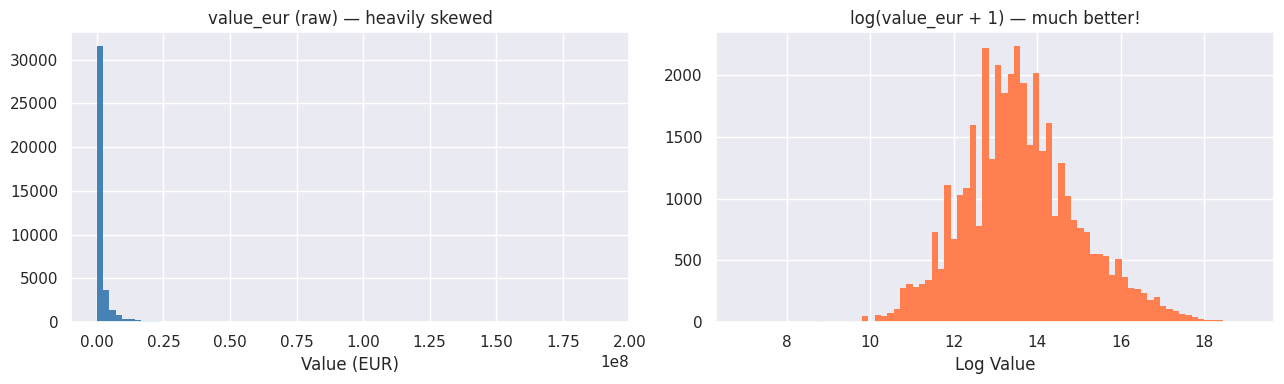

In [6]:
# ── Drop rows with missing target ────────────────────────────────────────────
df = df[df['value_eur'].notna() & (df['value_eur'] > 0)].copy()
print(f'After dropping missing/zero value_eur: {df.shape}')

# ── Simplify player position → 4 classes (used later for feature) ────────────
def map_position(pos_str):
    if pd.isna(pos_str): return 'Unknown'
    pos = pos_str.split(',')[0].strip().upper()
    if pos == 'GK': return 'GK'
    if pos in ['CB','LB','RB','LWB','RWB','LCB','RCB']: return 'DEF'
    if pos in ['CM','CDM','CAM','LM','RM','LCM','RCM','LAM','RAM','LCDM','RCDM']: return 'MID'
    return 'FWD'

df['position_group'] = df['player_positions'].apply(map_position)

# ── Encode categoricals ───────────────────────────────────────────────────────
df['preferred_foot_enc'] = (df['preferred_foot'] == 'Right').astype(int)
le_pos = LabelEncoder()
df['position_enc'] = le_pos.fit_transform(df['position_group'])

# ── Log-transform target (value_eur is highly skewed) ────────────────────────
df['log_value_eur'] = np.log1p(df['value_eur'])

print('\n📊 Target distribution (value_eur):')
print(df['value_eur'].describe().apply(lambda x: f'{x:,.0f}'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['value_eur'], bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('value_eur (raw) — heavily skewed')
axes[0].set_xlabel('Value (EUR)')
axes[1].hist(df['log_value_eur'], bins=80, color='coral', edgecolor='none')
axes[1].set_title('log(value_eur + 1) — much better!')
axes[1].set_xlabel('Log Value')
plt.tight_layout()
plt.show()

In [15]:
# ── Select numeric features ───────────────────────────────────────────────────
FEATURE_COLS = [
    'age', 'height_cm', 'weight_kg', 'overall', 'potential',
    'international_reputation', 'weak_foot', 'skill_moves',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'movement_reactions', 'movement_acceleration', 'movement_sprint_speed',
    'power_shot_power', 'power_stamina', 'power_strength', 'power_long_shots',
    'mentality_vision', 'mentality_positioning', 'mentality_aggression',
    'attacking_crossing', 'attacking_finishing', 'attacking_short_passing',
    'skill_dribbling', 'skill_ball_control', 'skill_long_passing',
    'defending_marking_awareness', 'defending_standing_tackle',
    'preferred_foot_enc', 'position_enc', 'league_level'
]

# Keep only existing columns
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

X = df[FEATURE_COLS].copy()
y = df['log_value_eur'].copy()   # log-transformed target

# Fill missing with median
X = X.fillna(X.median())

print(f'Feature matrix: {X.shape}')
print(f'Target shape  : {y.shape}')

Feature matrix: (39507, 35)
Target shape  : (39507,)


In [42]:
# ── Train/Test Split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# ── Scale features ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape} | Test: {X_test_sc.shape}')

Train: (31605, 35) | Test: (7902, 35)


## 📐 Step 5: Evaluation Utility

In [43]:
def evaluate_model(name, y_true, y_pred):
    """
    y_true and y_pred are in log-space.
    We exponentiate back before computing MAPE / RMSLE on original scale,
    but compute MSE/MAE/R2 in log-space (standard for skewed targets).
    """
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    med_ae = median_absolute_error(y_true, y_pred)

    # RMSLE on original scale
    y_orig_true = np.expm1(y_true)
    y_orig_pred = np.expm1(y_pred)
    y_orig_pred_clipped = np.clip(y_orig_pred, 0, None)
    try:
        msle = mean_squared_log_error(y_orig_true, y_orig_pred_clipped)
        rmsle = np.sqrt(msle)
    except Exception:
        rmsle = np.nan

    results = {
        'Model': name,
        'MSE (log)': round(mse, 4),
        'RMSE (log)': round(rmse, 4),
        'MAE (log)': round(mae, 4),
        'MAPE (%)': round(mape, 2),
        'R²': round(r2, 4),
        'Median AE': round(med_ae, 4),
        'RMSLE': round(rmsle, 4) if not np.isnan(rmsle) else 'N/A'
    }
    return results

all_results = []
print('✅ Evaluation function ready!')

✅ Evaluation function ready!


---
## 🔵 Model 1: Linear Regression

In [44]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

res_lr = evaluate_model('Linear Regression', y_test, y_pred_lr)
all_results.append(res_lr)
print(pd.Series(res_lr))

Model         Linear Regression
MSE (log)                0.1488
RMSE (log)               0.3857
MAE (log)                0.2825
MAPE (%)                   2.15
R²                       0.9196
Median AE                0.2305
RMSLE                    0.3857
dtype: object


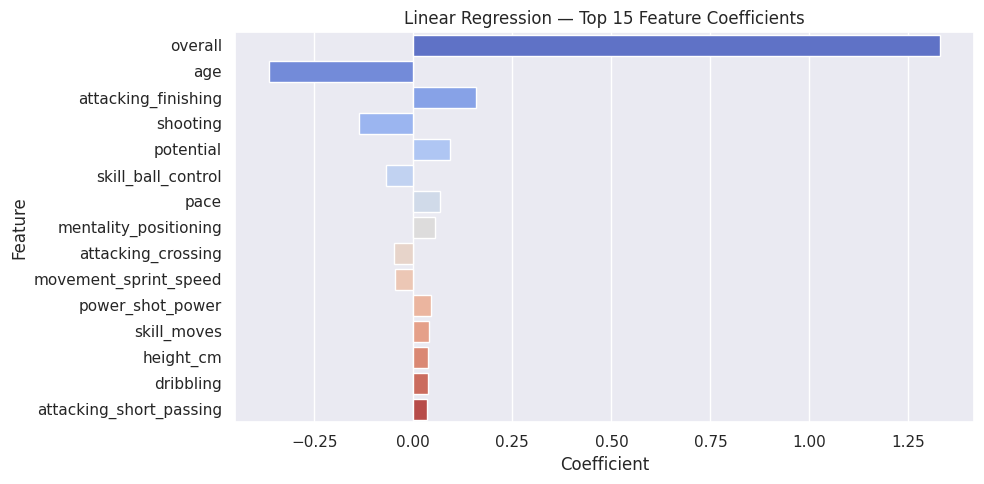

In [45]:
# Top feature importances (coefficients)
coef_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 5))
sns.barplot(data=coef_df.head(15), x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Linear Regression — Top 15 Feature Coefficients')
plt.tight_layout()
plt.show()

---
## 🟠 Model 2: Kernel Regression (Kernel Ridge — RBF Kernel)

### 💡 Kernel Trick Explanation
> The **kernel trick** maps input features into a higher-dimensional (even infinite-dimensional) feature space **implicitly**, without ever computing the transformation explicitly. Instead of working with raw features $\mathbf{x}$, a kernel function $k(\mathbf{x}_i, \mathbf{x}_j)$ computes the dot product in that high-dimensional space directly.
>
> For regression, **Kernel Ridge Regression** uses an RBF (Gaussian) kernel:
> $$k(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$$
> This lets the model fit **non-linear** relationships between features and the target without manually engineering non-linear features. It's especially useful when the data has complex, curved patterns that a straight line can't capture — like the relationship between `overall` rating and `value_eur` which is exponential, not linear.

In [46]:
# Kernel Regression is memory-intensive — use a subsample to avoid Colab crash
KR_SAMPLE = 6000
idx_kr = np.random.choice(len(X_train_sc), size=KR_SAMPLE, replace=False)
X_train_kr = X_train_sc[idx_kr]
y_train_kr = y_train.values[idx_kr]

kr = KernelRidge(kernel='rbf', alpha=0.5, gamma=0.05)
kr.fit(X_train_kr, y_train_kr)
y_pred_kr = kr.predict(X_test_sc)

res_kr = evaluate_model('Kernel Ridge (RBF)', y_test, y_pred_kr)
all_results.append(res_kr)
print(pd.Series(res_kr))
print(f'\n(Trained on {KR_SAMPLE} samples to prevent RAM overflow)')

Model         Kernel Ridge (RBF)
MSE (log)                 0.9655
RMSE (log)                0.9826
MAE (log)                 0.6562
MAPE (%)                     4.8
R²                        0.4781
Median AE                 0.4619
RMSLE                     0.9826
dtype: object

(Trained on 6000 samples to prevent RAM overflow)


---
## 🟡 Model 3: Ridge Regression

In [47]:
from sklearn.model_selection import GridSearchCV

ridge = Ridge()
param_grid_ridge = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
ridge_cv = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='r2', n_jobs=-1)
ridge_cv.fit(X_train_sc, y_train)

best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_sc)

res_ridge = evaluate_model('Ridge Regression', y_test, y_pred_ridge)
all_results.append(res_ridge)
print(f'Best alpha: {ridge_cv.best_params_}')
print(pd.Series(res_ridge))

Best alpha: {'alpha': 1.0}
Model         Ridge Regression
MSE (log)               0.1488
RMSE (log)              0.3857
MAE (log)               0.2825
MAPE (%)                  2.15
R²                      0.9196
Median AE               0.2305
RMSLE                   0.3857
dtype: object


---
## 🟢 Model 4: LASSO Regression

In [48]:
lasso = Lasso(max_iter=5000)
param_grid_lasso = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}
lasso_cv = GridSearchCV(lasso, param_grid_lasso, cv=5, scoring='r2', n_jobs=-1)
lasso_cv.fit(X_train_sc, y_train)

best_lasso = lasso_cv.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_sc)

res_lasso = evaluate_model('LASSO Regression', y_test, y_pred_lasso)
all_results.append(res_lasso)

n_zero = np.sum(best_lasso.coef_ == 0)
print(f'Best alpha: {lasso_cv.best_params_}')
print(f'Features zeroed out by LASSO: {n_zero}/{len(FEATURE_COLS)}')
print(pd.Series(res_lasso))

Best alpha: {'alpha': 0.0001}
Features zeroed out by LASSO: 2/35
Model         LASSO Regression
MSE (log)               0.1488
RMSE (log)              0.3857
MAE (log)               0.2825
MAPE (%)                  2.15
R²                      0.9196
Median AE                 0.23
RMSLE                   0.3857
dtype: object


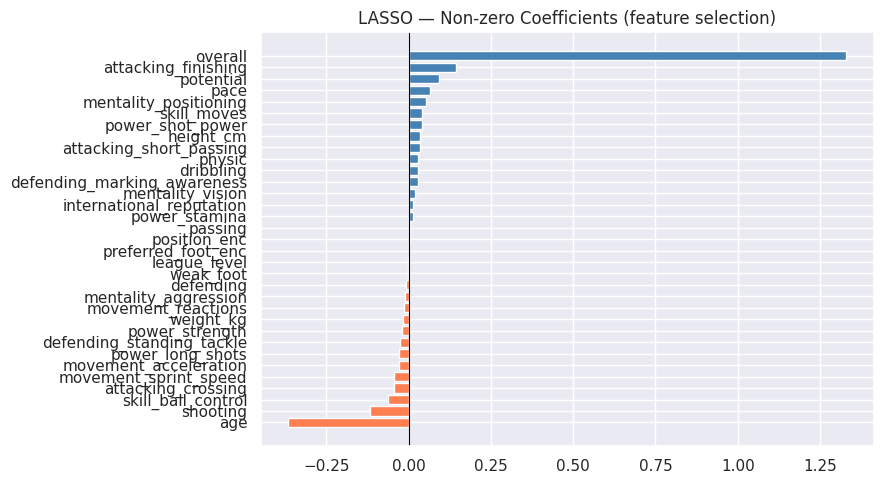

In [49]:
# LASSO coefficient sparsity plot
lasso_coef = pd.DataFrame({'Feature': FEATURE_COLS, 'Coefficient': best_lasso.coef_})
lasso_coef = lasso_coef[lasso_coef['Coefficient'] != 0]
lasso_coef = lasso_coef.sort_values('Coefficient')

plt.figure(figsize=(9, 5))
colors = ['coral' if v < 0 else 'steelblue' for v in lasso_coef['Coefficient']]
plt.barh(lasso_coef['Feature'], lasso_coef['Coefficient'], color=colors)
plt.title('LASSO — Non-zero Coefficients (feature selection)')
plt.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

---
## 🔷 Optional Model 5: Polynomial Regression (degree=2)

In [50]:
# Use only top 10 features to avoid memory explosion with polynomial expansion
TOP_FEATURES_POLY = ['overall', 'potential', 'age', 'international_reputation',
                     'skill_moves', 'weak_foot', 'movement_reactions',
                     'mentality_vision', 'attacking_finishing', 'pace']
TOP_FEATURES_POLY = [f for f in TOP_FEATURES_POLY if f in FEATURE_COLS]

idx_top = [FEATURE_COLS.index(f) for f in TOP_FEATURES_POLY]
X_train_poly_raw = X_train_sc[:, idx_top]
X_test_poly_raw  = X_test_sc[:, idx_top]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_poly_raw)
X_test_poly  = poly.transform(X_test_poly_raw)

poly_lr = Ridge(alpha=1.0)   # Use Ridge to regularize expanded features
poly_lr.fit(X_train_poly, y_train)
y_pred_poly = poly_lr.predict(X_test_poly)

res_poly = evaluate_model('Polynomial Regression (deg=2)', y_test, y_pred_poly)
all_results.append(res_poly)
print(f'Polynomial feature count: {X_train_poly.shape[1]}')
print(pd.Series(res_poly))

Polynomial feature count: 65
Model         Polynomial Regression (deg=2)
MSE (log)                            0.1056
RMSE (log)                            0.325
MAE (log)                            0.2468
MAPE (%)                               1.87
R²                                   0.9429
Median AE                            0.2113
RMSLE                                 0.325
dtype: object


---
## 🔶 Optional Model 6: Bayesian Ridge Regression

In [51]:
bayes_ridge = BayesianRidge(max_iter=500)
bayes_ridge.fit(X_train_sc, y_train)
y_pred_bayes = bayes_ridge.predict(X_test_sc)

res_bayes = evaluate_model('Bayesian Ridge', y_test, y_pred_bayes)
all_results.append(res_bayes)
print(pd.Series(res_bayes))

Model         Bayesian Ridge
MSE (log)             0.1488
RMSE (log)            0.3857
MAE (log)             0.2825
MAPE (%)                2.15
R²                    0.9196
Median AE             0.2305
RMSLE                 0.3857
dtype: object


---
## 🟤 Optional Model 7: Elastic Net

In [52]:
enet = ElasticNet(max_iter=5000)
param_grid_enet = {'alpha': [0.001, 0.01, 0.1], 'l1_ratio': [0.2, 0.5, 0.8]}
enet_cv = GridSearchCV(enet, param_grid_enet, cv=5, scoring='r2', n_jobs=-1)
enet_cv.fit(X_train_sc, y_train)

y_pred_enet = enet_cv.best_estimator_.predict(X_test_sc)
res_enet = evaluate_model('Elastic Net', y_test, y_pred_enet)
all_results.append(res_enet)
print(f'Best params: {enet_cv.best_params_}')
print(pd.Series(res_enet))

Best params: {'alpha': 0.001, 'l1_ratio': 0.2}
Model         Elastic Net
MSE (log)          0.1488
RMSE (log)         0.3857
MAE (log)          0.2825
MAPE (%)             2.15
R²                 0.9196
Median AE            0.23
RMSLE              0.3857
dtype: object


---
## 🌳 Optional Model 8: Decision Tree Regression

In [53]:
dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)

res_dt = evaluate_model('Decision Tree', y_test, y_pred_dt)
all_results.append(res_dt)
print(pd.Series(res_dt))

Model         Decision Tree
MSE (log)            0.1229
RMSE (log)           0.3506
MAE (log)            0.2634
MAPE (%)                2.0
R²                   0.9336
Median AE            0.2238
RMSLE                0.3506
dtype: object


---
## 🤖 Optional Model 9: SVR

In [54]:
# SVR is slow on large data — subsample
SVR_SAMPLE = 8000
idx_svr = np.random.choice(len(X_train_sc), size=SVR_SAMPLE, replace=False)
X_train_svr = X_train_sc[idx_svr]
y_train_svr = y_train.values[idx_svr]

svr = SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1)
svr.fit(X_train_svr, y_train_svr)
y_pred_svr = svr.predict(X_test_sc)

res_svr = evaluate_model('SVR (RBF)', y_test, y_pred_svr)
all_results.append(res_svr)
print(pd.Series(res_svr))
print(f'(Trained on {SVR_SAMPLE} samples)')

Model         SVR (RBF)
MSE (log)        0.1131
RMSE (log)       0.3363
MAE (log)         0.244
MAPE (%)           1.85
R²               0.9389
Median AE        0.1915
RMSLE            0.3363
dtype: object
(Trained on 8000 samples)


---
## 🌲 Optional Model 10: Random Forest Regressor

In [55]:
rf = RandomForestRegressor(
    n_estimators=200, max_depth=12, min_samples_leaf=10,
    n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

res_rf = evaluate_model('Random Forest', y_test, y_pred_rf)
all_results.append(res_rf)
print(pd.Series(res_rf))

Model         Random Forest
MSE (log)            0.1001
RMSE (log)           0.3164
MAE (log)            0.2361
MAPE (%)               1.79
R²                   0.9459
Median AE            0.1968
RMSLE                0.3164
dtype: object


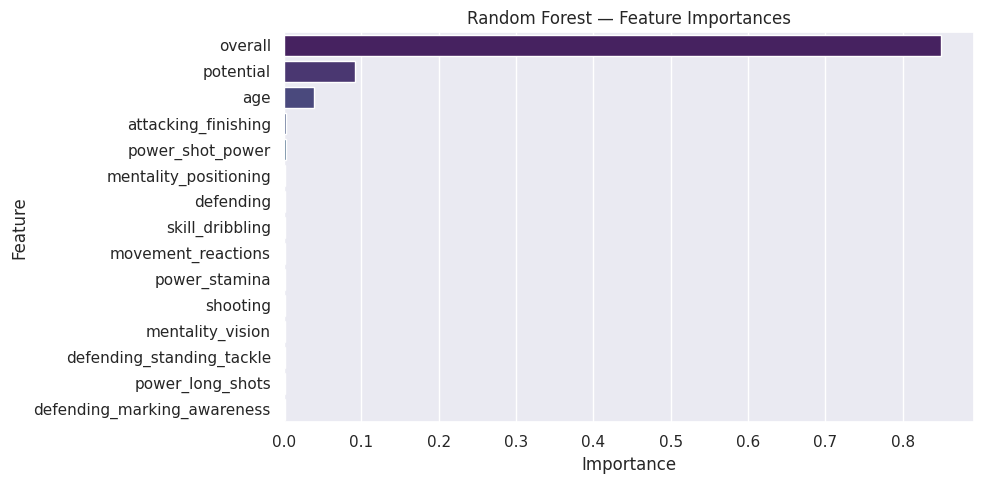

In [56]:
# Feature importance
fi_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': rf.feature_importances_})
fi_df = fi_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest — Feature Importances')
plt.tight_layout()
plt.show()

---
## ⚡ Optional Model 11: XGBoost Regressor

In [57]:
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    tree_method='hist',   # Fast, memory-efficient
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
xgb.fit(
    X_train_sc, y_train,
    eval_set=[(X_test_sc, y_test)],
    verbose=False
)
y_pred_xgb = xgb.predict(X_test_sc)

res_xgb = evaluate_model('XGBoost', y_test, y_pred_xgb)
all_results.append(res_xgb)
print(pd.Series(res_xgb))

Model         XGBoost
MSE (log)      0.0848
RMSE (log)     0.2912
MAE (log)      0.2156
MAPE (%)         1.63
R²             0.9542
Median AE      0.1785
RMSLE          0.2912
dtype: object


---
## 📊 Step 6: Full Comparison Table & Visualizations

In [58]:
results_df = pd.DataFrame(all_results).set_index('Model')
results_df = results_df.sort_values('R²', ascending=False)
print('\n🏆 Model Performance Summary (sorted by R²):')
results_df


🏆 Model Performance Summary (sorted by R²):


,MSE (log),RMSE (log),MAE (log),MAPE (%),R²,Median AE,RMSLE
Model,,,,,,,
XGBoost,0.0848,0.2912,0.2156,1.63,0.9542,0.1785,0.2912
Random Forest,0.1001,0.3164,0.2361,1.79,0.9459,0.1968,0.3164
Polynomial Regression (deg=2),0.1056,0.3250,0.2468,1.87,0.9429,0.2113,0.3250
SVR (RBF),0.1131,0.3363,0.2440,1.85,0.9389,0.1915,0.3363
Decision Tree,0.1229,0.3506,0.2634,2.00,0.9336,0.2238,0.3506
Linear Regression,0.1488,0.3857,0.2825,2.15,0.9196,0.2305,0.3857
Ridge Regression,0.1488,0.3857,0.2825,2.15,0.9196,0.2305,0.3857
LASSO Regression,0.1488,0.3857,0.2825,2.15,0.9196,0.2300,0.3857
Elastic Net,0.1488,0.3857,0.2825,2.15,0.9196,0.2300,0.3857


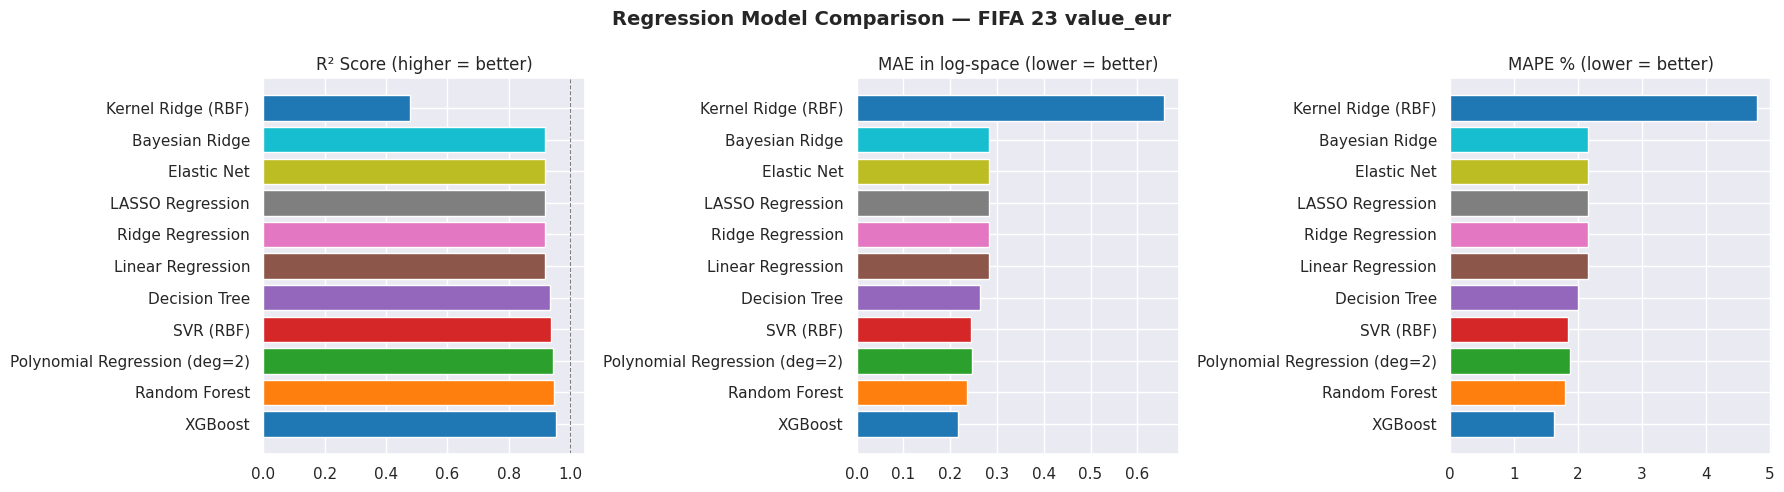

In [59]:
# ── Bar chart: R² comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = sns.color_palette('tab10', len(results_df))

# R²
r2_vals = results_df['R²'].astype(float)
axes[0].barh(r2_vals.index, r2_vals.values, color=colors)
axes[0].set_title('R² Score (higher = better)')
axes[0].set_xlim(0, 1.05)
axes[0].axvline(1.0, ls='--', color='gray', lw=0.8)

# MAE
mae_vals = results_df['MAE (log)'].astype(float)
axes[1].barh(mae_vals.index, mae_vals.values, color=colors)
axes[1].set_title('MAE in log-space (lower = better)')

# MAPE
mape_vals = results_df['MAPE (%)'].astype(float)
axes[2].barh(mape_vals.index, mape_vals.values, color=colors)
axes[2].set_title('MAPE % (lower = better)')

plt.suptitle('Regression Model Comparison — FIFA 23 value_eur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

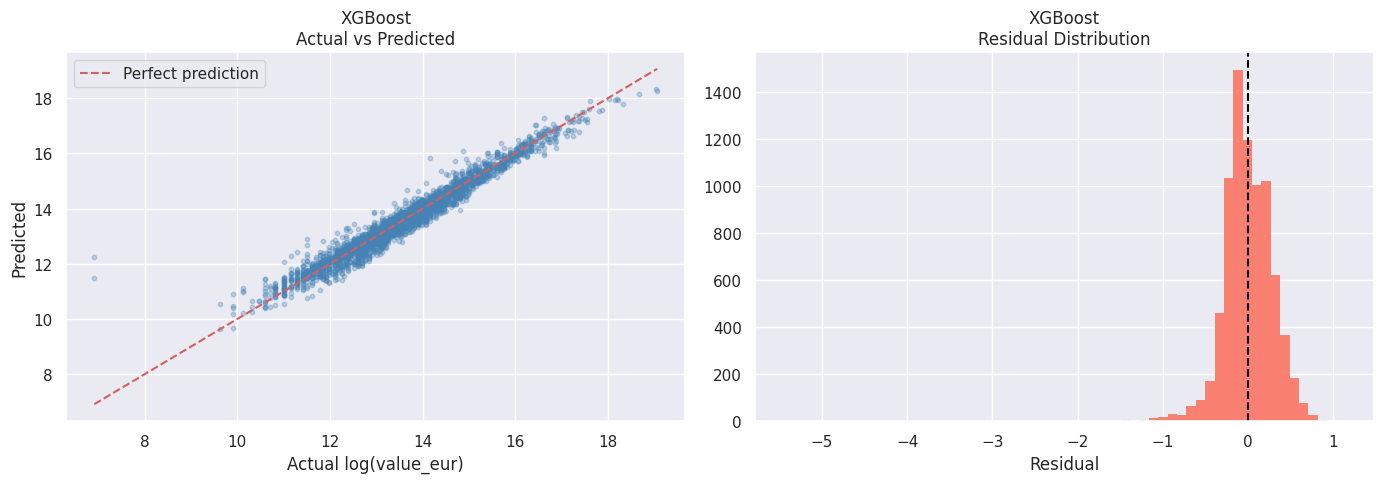

In [60]:
# ── Actual vs Predicted for best model ───────────────────────────────────────
best_model_name = results_df.index[0]
pred_map = {
    'Linear Regression': y_pred_lr,
    'Kernel Ridge (RBF)': y_pred_kr,
    'Ridge Regression': y_pred_ridge,
    'LASSO Regression': y_pred_lasso,
    'Polynomial Regression (deg=2)': y_pred_poly,
    'Bayesian Ridge': y_pred_bayes,
    'Elastic Net': y_pred_enet,
    'Decision Tree': y_pred_dt,
    'SVR (RBF)': y_pred_svr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
}

best_pred = pred_map[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
sample = np.random.choice(len(y_test), size=min(3000, len(y_test)), replace=False)
axes[0].scatter(y_test.values[sample], best_pred[sample], alpha=0.3, s=10, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual log(value_eur)')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{best_model_name}\nActual vs Predicted')
axes[0].legend()

# Residuals
residuals = y_test.values - best_pred
axes[1].hist(residuals, bins=60, color='salmon', edgecolor='none')
axes[1].axvline(0, color='black', lw=1.5, ls='--')
axes[1].set_xlabel('Residual')
axes[1].set_title(f'{best_model_name}\nResidual Distribution')

plt.tight_layout()
plt.show()

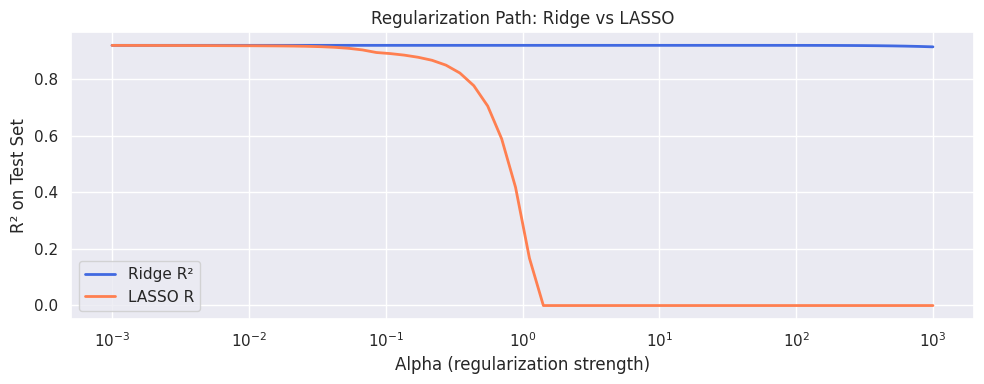

In [61]:
# ── Ridge vs LASSO regularization path ───────────────────────────────────────
alphas = np.logspace(-3, 3, 60)
ridge_r2 = [r2_score(y_test, Ridge(alpha=a).fit(X_train_sc, y_train).predict(X_test_sc)) for a in alphas]
lasso_r2 = [r2_score(y_test, Lasso(alpha=a, max_iter=3000).fit(X_train_sc, y_train).predict(X_test_sc)) for a in alphas]

plt.figure(figsize=(10, 4))
plt.semilogx(alphas, ridge_r2, label='Ridge R²', color='royalblue', lw=2)
plt.semilogx(alphas, lasso_r2, label='LASSO R', color='coral', lw=2)
plt.xlabel('Alpha (regularization strength)')
plt.ylabel('R² on Test Set')
plt.title('Regularization Path: Ridge vs LASSO')
plt.legend()
plt.tight_layout()
plt.show()

---
## 📝 Step 7: Discussion Questions

### ❓ Q1: Which metric is best for this dataset and why?

**Best metric: RMSLE (Root Mean Squared Logarithmic Error)**

The `value_eur` distribution is **heavily right-skewed** — most players are worth under €1M, but superstars can exceed €100M. In this setting:
- **MSE/RMSE** would be dominated by expensive players; a €5M error on Messi matters less than a €5M error on an average player.
- **MAPE** and **RMSLE** treat relative errors equally — being off by 20% is the same whether it's €200K or €20M.
- **R²** is useful for overall model fit but doesn't reflect the skewness issue.

By log-transforming the target (`log1p(value_eur)`) and using **RMSLE**, we make the regression fair across all player value levels. This is why RMSLE is the standard for price/market-value prediction tasks.

---

### ❓ Q2: When is each regression model preferable?

| Model | When to use |
|---|---|
| **Linear Regression** | Baseline; when features have a linear relationship with target; interpretability is key |
| **Ridge Regression** | When multicollinearity exists among features (many correlated FIFA stats); shrinks all coefficients |
| **LASSO Regression** | When you suspect many features are irrelevant; performs automatic feature selection (zeroes out weak features) |
| **Elastic Net** | Combines Ridge + LASSO; best when both sparsity and stability are needed |
| **Kernel Regression** | When relationship is non-linear; can model complex interactions without manual feature engineering |
| **Polynomial Regression** | When a specific polynomial relationship is known; degree must be controlled to avoid overfitting |
| **Bayesian Ridge** | When you have small data and need uncertainty estimates; provides probabilistic predictions |
| **Decision Tree** | Interpretable non-linear model; handles categorical features natively; prone to overfitting without pruning |
| **SVR** | Effective in high dimensions; robust to outliers; slow on large datasets |
| **Random Forest** | Robust ensemble; handles missing data; great default choice for tabular data |
| **XGBoost** | Best for tabular data competitions; handles skewed distributions well; fastest tree-based method |

---

### ❓ Q3: Kernel Trick Explanation

The **kernel trick** is a mathematical technique that allows algorithms to operate in a **high-dimensional feature space without explicitly computing coordinates** in that space. Instead, it computes the **inner product (similarity)** between two data points in that space using a kernel function.

**Why it helps in regression:**
The relationship between FIFA stats and player value is not linear — for example, moving `overall` from 60→70 has a smaller impact on value than 80→90 (exponential effect). Kernel Ridge Regression with an **RBF kernel** can capture these non-linear patterns:
$$k(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$$
This measures how **similar** two players are in feature space, and the model learns to predict value based on these similarities. Players close in feature space get similar predictions, allowing smooth non-linear curves to be fit — all without explicitly computing the infinite-dimensional transformation.

**In summary:** The kernel trick lets us get the power of non-linear models (fitting complex curves) at the computational cost of a linear model, as long as we can evaluate pairwise similarities efficiently.

In [62]:
# ── Final styled summary table ────────────────────────────────────────────────
print('\n' + '='*70)
print('        🏆 FINAL REGRESSION RESULTS — FIFA 23 value_eur')
print('='*70)
print(results_df.to_string())
print('='*70)
print(f'\n🥇 Best model by R²  : {results_df["R²"].astype(float).idxmax()}')
print(f'🥇 Best model by MAE : {results_df["MAE (log)"].astype(float).idxmin()}')
print(f'🥇 Best model by MAPE: {results_df["MAPE (%)"].astype(float).idxmin()}')


        🏆 FINAL REGRESSION RESULTS — FIFA 23 value_eur
                               MSE (log)  RMSE (log)  MAE (log)  MAPE (%)      R²  Median AE   RMSLE
Model                                                                                               
XGBoost                           0.0848      0.2912     0.2156      1.63  0.9542     0.1785  0.2912
Random Forest                     0.1001      0.3164     0.2361      1.79  0.9459     0.1968  0.3164
Polynomial Regression (deg=2)     0.1056      0.3250     0.2468      1.87  0.9429     0.2113  0.3250
SVR (RBF)                         0.1131      0.3363     0.2440      1.85  0.9389     0.1915  0.3363
Decision Tree                     0.1229      0.3506     0.2634      2.00  0.9336     0.2238  0.3506
Linear Regression                 0.1488      0.3857     0.2825      2.15  0.9196     0.2305  0.3857
Ridge Regression                  0.1488      0.3857     0.2825      2.15  0.9196     0.2305  0.3857
LASSO Regression                  0

---
# 🏆 Part 2: Binary Classification — FIFA 23
**Target:** Is the player **Elite**? (`overall >= 85` → 1, else → 0)

### Models Implemented:
1. Logistic Regression
2. Linear SVM
3. Kernel SVM (RBF)
4. KNN (tuned K)
5. Decision Tree (tuned max_depth)
6. Random Forest
7. Linear Discriminant Analysis (LDA) *(Bonus)*
8. Naive Bayes *(Bonus)*
9. Gradient Boosting / XGBoost *(Bonus)*

### Evaluation Metrics:
- Accuracy, Precision, Recall, F1-Score
- Confusion Matrix, ROC Curve, AUC
- Sensitivity, Specificity, PR AUC, Cross-Entropy *(Bonus)*



In [63]:
# ── Binary Classification: Extra Imports ──────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    log_loss, classification_report
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_score, StratifiedKFold

import matplotlib.gridspec as gridspec
from scipy.special import kl_div
from scipy.spatial.distance import jensenshannon

print('✅ Classification libraries loaded!')


✅ Classification libraries loaded!


## 🎯 Step 1: Create Binary Target — Elite Player
An **Elite player** is defined as `overall >= 85`. This gives a meaningful,
domain-informed binary split (top ~5% of players).



Class distribution:
  Non-Elite (0): 39,312  (99.5%)
  Elite     (1): 195  (0.5%)


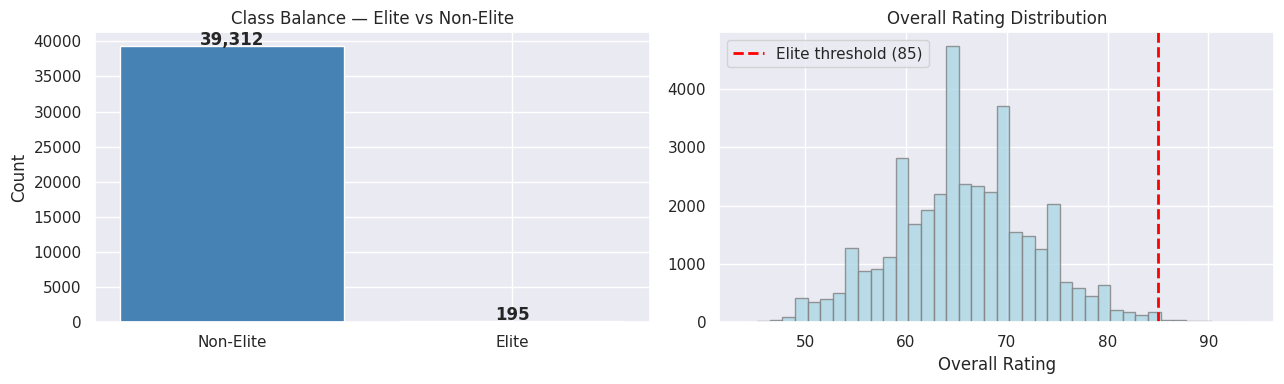

In [64]:
# ── Build classification dataset (reuse df from Part 1) ──────────────────────
df_clf = df.copy()

# Binary target: Elite (overall >= 85)
df_clf['is_elite'] = (df_clf['overall'] >= 85).astype(int)

elite_counts = df_clf['is_elite'].value_counts()
print('Class distribution:')
print(f'  Non-Elite (0): {elite_counts[0]:,}  ({100*elite_counts[0]/len(df_clf):.1f}%)')
print(f'  Elite     (1): {elite_counts[1]:,}  ({100*elite_counts[1]/len(df_clf):.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class balance
axes[0].bar(['Non-Elite', 'Elite'], [elite_counts[0], elite_counts[1]],
            color=['steelblue', 'gold'], edgecolor='white')
axes[0].set_title('Class Balance — Elite vs Non-Elite')
axes[0].set_ylabel('Count')
for i, v in enumerate([elite_counts[0], elite_counts[1]]):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Overall distribution with cutoff
axes[1].hist(df_clf['overall'], bins=40, color='lightblue', edgecolor='gray', alpha=0.8)
axes[1].axvline(85, color='red', lw=2, ls='--', label='Elite threshold (85)')
axes[1].set_title('Overall Rating Distribution')
axes[1].set_xlabel('Overall Rating')
axes[1].legend()

plt.tight_layout()
plt.show()


## 🔧 Step 2: Feature Matrix & Train/Test Split
We reuse the same FEATURE_COLS from Part 1, but **exclude `overall` and `potential`**
from the features to avoid data leakage (they directly determine the target).



In [65]:
# Exclude leakage features
LEAK_FEATURES = ['overall', 'potential']
CLF_FEATURES = [c for c in FEATURE_COLS if c not in LEAK_FEATURES]

X_clf = df_clf[CLF_FEATURES].fillna(df_clf[CLF_FEATURES].median())
y_clf = df_clf['is_elite']

print(f'Feature matrix : {X_clf.shape}')
print(f'Positive class : {y_clf.sum():,} ({100*y_clf.mean():.1f}%)')

# Stratified split to preserve class ratio
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

# Scale
scaler_clf = StandardScaler()
X_tr_sc = scaler_clf.fit_transform(X_tr)
X_te_sc  = scaler_clf.transform(X_te)

print(f'Train: {X_tr_sc.shape}  |  Test: {X_te_sc.shape}')
print(f'Elite in train: {y_tr.sum():,} | Elite in test: {y_te.sum():,}')


Feature matrix : (39507, 33)
Positive class : 195 (0.5%)
Train: (31605, 33)  |  Test: (7902, 33)
Elite in train: 156 | Elite in test: 39


## 📊 Step 3: Evaluation Utility for Classifiers


In [66]:
all_clf_results = []
roc_data = {}       # store (fpr, tpr, auc) for ROC plot
pr_data  = {}       # store (precision, recall, ap) for PR curve

def evaluate_clf(name, model, X_test, y_test, use_proba=True):
    """Full evaluation: standard + bonus metrics."""
    y_pred = model.predict(X_test)

    # Probability scores (needed for ROC / PR)
    if use_proba and hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        raw = model.decision_function(X_test)
        # Sigmoid squash to [0,1]
        y_score = 1 / (1 + np.exp(-raw))
    else:
        y_score = y_pred.astype(float)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_score)
    pr_auc = average_precision_score(y_test, y_score)

    # Confusion matrix derived metrics
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0   # = Recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Cross-Entropy
    ce = log_loss(y_test, np.clip(y_score, 1e-7, 1 - 1e-7))

    # Store ROC/PR
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_data[name] = (fpr, tpr, auc)
    p_curve, r_curve, _ = precision_recall_curve(y_test, y_score)
    pr_data[name] = (r_curve, p_curve, pr_auc)

    result = {
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'AUC-ROC': round(auc, 4),
        'PR-AUC': round(pr_auc, 4),
        'Sensitivity': round(sensitivity, 4),
        'Specificity': round(specificity, 4),
        'Cross-Entropy': round(ce, 4),
    }
    all_clf_results.append(result)
    return result, cm

print('✅ Evaluation function ready!')


✅ Evaluation function ready!


---
## 🔵 Model 1: Logistic Regression



Model            Logistic Regression
Accuracy                       0.989
Precision                     0.3065
Recall                        0.9744
F1-Score                      0.4663
AUC-ROC                        0.998
PR-AUC                        0.8296
Sensitivity                   0.9744
Specificity                   0.9891
Cross-Entropy                 0.0378
dtype: object


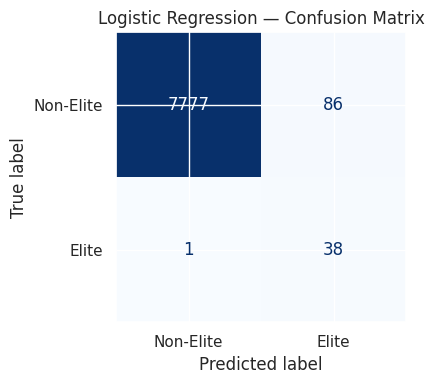

In [67]:
lr_clf = LogisticRegression(
    C=1.0, solver='lbfgs', max_iter=1000,
    class_weight='balanced', random_state=RANDOM_STATE
)
lr_clf.fit(X_tr_sc, y_tr)

res_lr_clf, cm_lr = evaluate_clf('Logistic Regression', lr_clf, X_te_sc, y_te)
print(pd.Series(res_lr_clf))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_lr, display_labels=['Non-Elite', 'Elite']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout(); plt.show()


---
## 🔴 Model 2: Linear SVM


Model            Linear SVM
Accuracy             0.9905
Precision            0.3302
Recall               0.8974
F1-Score             0.4828
AUC-ROC              0.9977
PR-AUC                0.813
Sensitivity          0.8974
Specificity           0.991
Cross-Entropy        0.0073
dtype: object


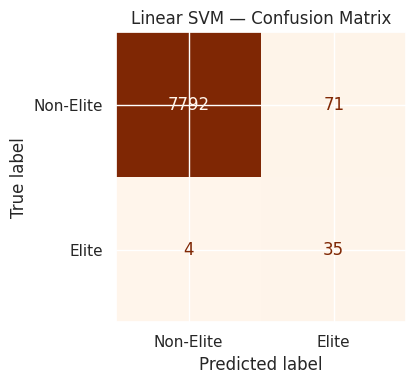

In [68]:
lin_svm = SVC(
    kernel='linear', C=1.0,
    class_weight='balanced', probability=True, random_state=RANDOM_STATE
)
lin_svm.fit(X_tr_sc, y_tr)

res_lin_svm, cm_lin_svm = evaluate_clf('Linear SVM', lin_svm, X_te_sc, y_te)
print(pd.Series(res_lin_svm))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_lin_svm, display_labels=['Non-Elite', 'Elite']).plot(
    ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Linear SVM — Confusion Matrix')
plt.tight_layout(); plt.show()


---
## 🟠 Model 3: Kernel SVM (RBF)


Model            Kernel SVM (RBF)
Accuracy                   0.9957
Precision                   0.551
Recall                     0.6923
F1-Score                   0.6136
AUC-ROC                    0.9925
PR-AUC                     0.6951
Sensitivity                0.6923
Specificity                0.9972
Cross-Entropy              0.0102
dtype: object
(Trained on 10,000 samples)


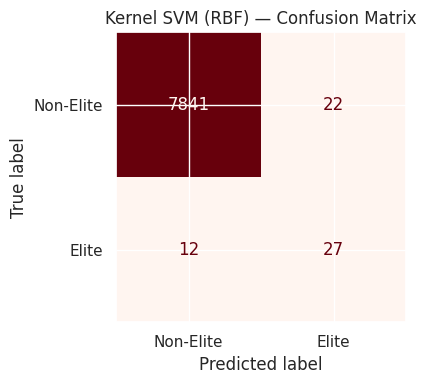

In [69]:
# RBF kernel SVM — subsample for speed
SVM_SAMPLE = 10_000
idx_svm = np.random.choice(len(X_tr_sc), size=SVM_SAMPLE, replace=False)

rbf_svm = SVC(
    kernel='rbf', C=10.0, gamma='scale',
    class_weight='balanced', probability=True, random_state=RANDOM_STATE
)
rbf_svm.fit(X_tr_sc[idx_svm], y_tr.values[idx_svm])

res_rbf_svm, cm_rbf_svm = evaluate_clf('Kernel SVM (RBF)', rbf_svm, X_te_sc, y_te)
print(pd.Series(res_rbf_svm))
print(f'(Trained on {SVM_SAMPLE:,} samples)')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_rbf_svm, display_labels=['Non-Elite', 'Elite']).plot(
    ax=ax, colorbar=False, cmap='Reds')
ax.set_title('Kernel SVM (RBF) — Confusion Matrix')
plt.tight_layout(); plt.show()


---
## 🟡 Model 4: K-Nearest Neighbors (KNN) — Tuned K
We search over multiple values of K using cross-validation to find the optimal number of neighbors.


  K= 1  CV-F1=0.6038
  K= 3  CV-F1=0.5862
  K= 5  CV-F1=0.5411
  K= 7  CV-F1=0.5260
  K= 9  CV-F1=0.4497
  K=11  CV-F1=0.4567
  K=13  CV-F1=0.4482
  K=15  CV-F1=0.4111
  K=17  CV-F1=0.3832
  K=19  CV-F1=0.3582
  K=21  CV-F1=0.2949
  K=23  CV-F1=0.2965
  K=25  CV-F1=0.2629

✅ Best K = 1  (CV-F1 = 0.6038)


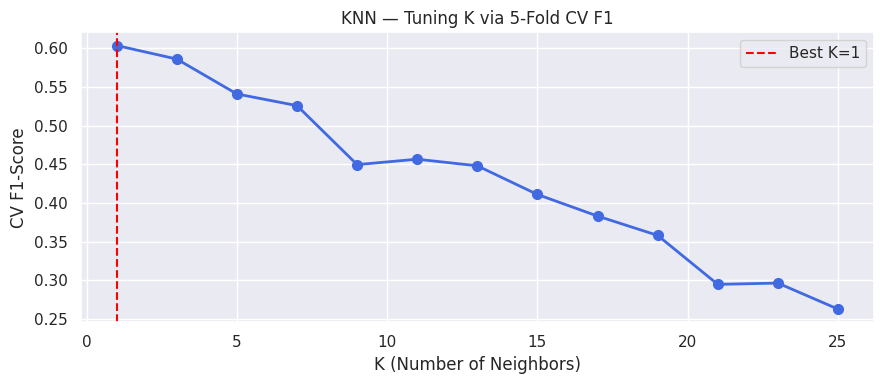

In [70]:
# ── Tune K ───────────────────────────────────────────────────────────────────
k_values = list(range(1, 26, 2))   # 1, 3, 5, ..., 25
cv_f1 = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    scores = cross_val_score(knn_tmp, X_tr_sc, y_tr, cv=cv, scoring='f1', n_jobs=-1)
    cv_f1.append(scores.mean())
    print(f'  K={k:2d}  CV-F1={scores.mean():.4f}')

best_k = k_values[np.argmax(cv_f1)]
print(f'\n✅ Best K = {best_k}  (CV-F1 = {max(cv_f1):.4f})')

# Plot K tuning
plt.figure(figsize=(9, 4))
plt.plot(k_values, cv_f1, 'o-', color='royalblue', lw=2, ms=7)
plt.axvline(best_k, color='red', ls='--', lw=1.5, label=f'Best K={best_k}')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('CV F1-Score')
plt.title('KNN — Tuning K via 5-Fold CV F1')
plt.legend(); plt.tight_layout(); plt.show()


Model            KNN (K=1)
Accuracy            0.9961
Precision              0.6
Recall              0.6154
F1-Score            0.6076
AUC-ROC             0.8067
PR-AUC              0.3711
Sensitivity         0.6154
Specificity          0.998
Cross-Entropy       0.0632
dtype: object


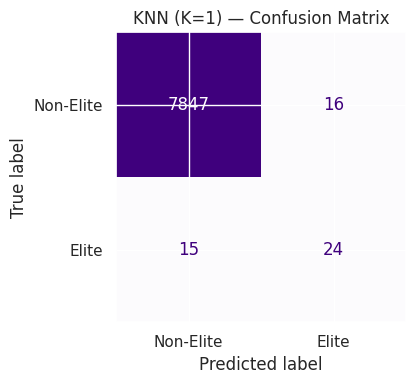

In [71]:
# ── Train best KNN ───────────────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_tr_sc, y_tr)

res_knn, cm_knn = evaluate_clf('KNN (K={})'.format(best_k), knn, X_te_sc, y_te)
print(pd.Series(res_knn))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_knn, display_labels=['Non-Elite', 'Elite']).plot(
    ax=ax, colorbar=False, cmap='Purples')
ax.set_title(f'KNN (K={best_k}) — Confusion Matrix')
plt.tight_layout(); plt.show()


---
## 🌳 Model 5: Decision Tree — Tuned max_depth
We tune `max_depth` to balance bias and variance and avoid overfitting.


Best max_depth = 14  (Test F1 = 0.5289)


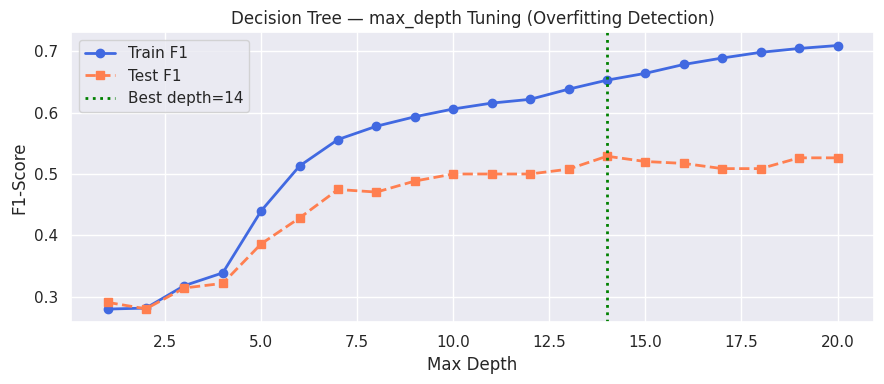

In [72]:
# ── Tune max_depth ───────────────────────────────────────────────────────────
depths = list(range(1, 21))
train_f1, test_f1 = [], []

for d in depths:
    dt_tmp = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=RANDOM_STATE)
    dt_tmp.fit(X_tr_sc, y_tr)
    train_f1.append(f1_score(y_tr, dt_tmp.predict(X_tr_sc)))
    test_f1.append(f1_score(y_te, dt_tmp.predict(X_te_sc)))

best_depth = depths[np.argmax(test_f1)]
print(f'Best max_depth = {best_depth}  (Test F1 = {max(test_f1):.4f})')

plt.figure(figsize=(9, 4))
plt.plot(depths, train_f1, 'o-', label='Train F1', color='royalblue', lw=2)
plt.plot(depths, test_f1,  's--', label='Test F1',  color='coral',     lw=2)
plt.axvline(best_depth, color='green', ls=':', lw=2, label=f'Best depth={best_depth}')
plt.xlabel('Max Depth')
plt.ylabel('F1-Score')
plt.title('Decision Tree — max_depth Tuning (Overfitting Detection)')
plt.legend(); plt.tight_layout(); plt.show()


Model            Decision Tree (depth=14)
Accuracy                           0.9889
Precision                           0.287
Recall                             0.8462
F1-Score                           0.4286
AUC-ROC                            0.9214
PR-AUC                             0.6728
Sensitivity                        0.8462
Specificity                        0.9896
Cross-Entropy                      0.0494
dtype: object


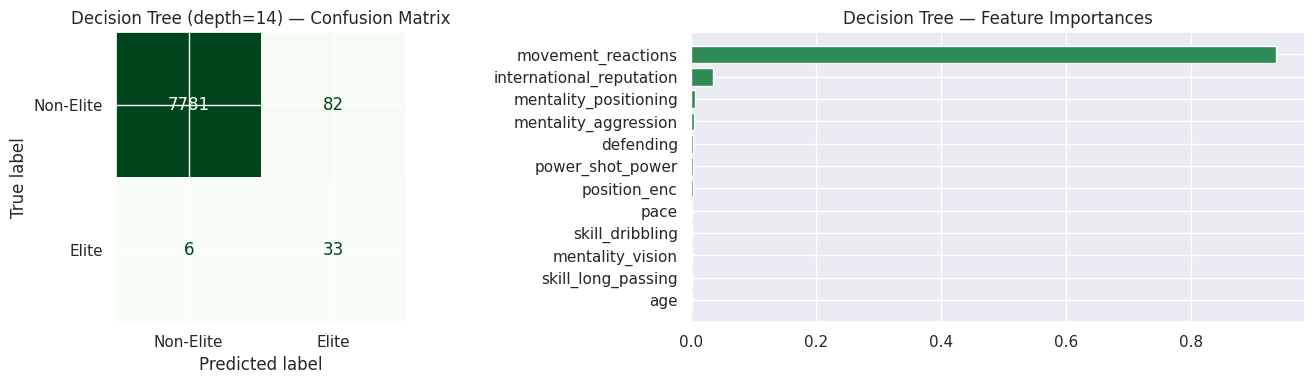

In [73]:
# ── Train best Decision Tree ──────────────────────────────────────────────────
dt_clf = DecisionTreeClassifier(
    max_depth=best_depth, min_samples_leaf=20,
    class_weight='balanced', random_state=RANDOM_STATE
)
dt_clf.fit(X_tr_sc, y_tr)

res_dt_clf, cm_dt = evaluate_clf(f'Decision Tree (depth={best_depth})', dt_clf, X_te_sc, y_te)
print(pd.Series(res_dt_clf))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ConfusionMatrixDisplay(cm_dt, display_labels=['Non-Elite', 'Elite']).plot(
    ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title(f'Decision Tree (depth={best_depth}) — Confusion Matrix')

# Feature importances
fi = pd.DataFrame({'Feature': CLF_FEATURES, 'Importance': dt_clf.feature_importances_})
fi = fi[fi['Importance'] > 0].sort_values('Importance', ascending=True).tail(12)
axes[1].barh(fi['Feature'], fi['Importance'], color='seagreen')
axes[1].set_title('Decision Tree — Feature Importances')
plt.tight_layout(); plt.show()


---
## 🌲 Model 6: Random Forest



Model            Random Forest
Accuracy                0.9951
Precision                  0.5
Recall                  0.9487
F1-Score                0.6549
AUC-ROC                 0.9991
PR-AUC                  0.8671
Sensitivity             0.9487
Specificity             0.9953
Cross-Entropy           0.0124
dtype: object


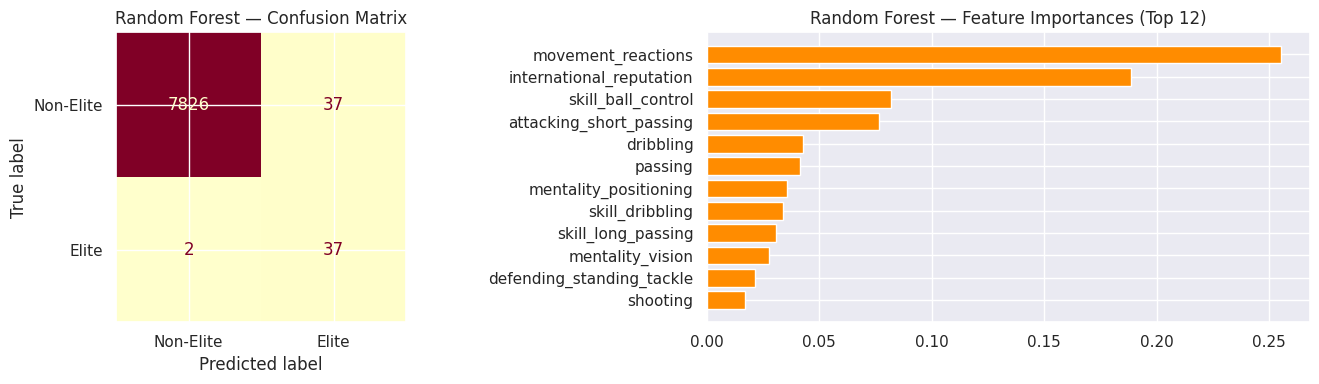

In [74]:
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=10,
    class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
)
rf_clf.fit(X_tr_sc, y_tr)

res_rf_clf, cm_rf = evaluate_clf('Random Forest', rf_clf, X_te_sc, y_te)
print(pd.Series(res_rf_clf))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ConfusionMatrixDisplay(cm_rf, display_labels=['Non-Elite', 'Elite']).plot(
    ax=axes[0], colorbar=False, cmap='YlOrRd')
axes[0].set_title('Random Forest — Confusion Matrix')

fi_rf = pd.DataFrame({'Feature': CLF_FEATURES, 'Importance': rf_clf.feature_importances_})
fi_rf = fi_rf.sort_values('Importance', ascending=True).tail(12)
axes[1].barh(fi_rf['Feature'], fi_rf['Importance'], color='darkorange')
axes[1].set_title('Random Forest — Feature Importances (Top 12)')
plt.tight_layout(); plt.show()


---
## 🧪 Bonus Model 7: Linear Discriminant Analysis (LDA)


Model               LDA
Accuracy         0.9839
Precision        0.2215
Recall           0.8974
F1-Score         0.3553
AUC-ROC          0.9945
PR-AUC           0.6251
Sensitivity      0.8974
Specificity      0.9844
Cross-Entropy     0.143
dtype: object


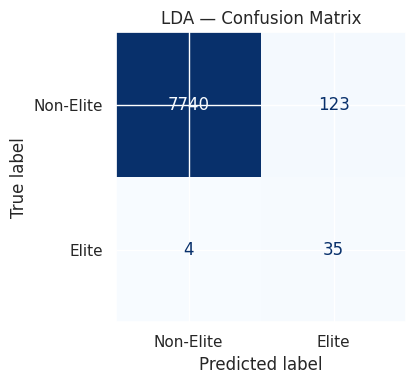

In [75]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_tr_sc, y_tr)

res_lda, cm_lda = evaluate_clf('LDA', lda, X_te_sc, y_te)
print(pd.Series(res_lda))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_lda, display_labels=['Non-Elite', 'Elite']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('LDA — Confusion Matrix')
plt.tight_layout(); plt.show()


---
## 🧪 Bonus Model 8: Naive Bayes (Gaussian)


Model            Naive Bayes (GNB)
Accuracy                    0.9107
Precision                   0.0499
Recall                      0.9487
F1-Score                    0.0949
AUC-ROC                     0.9881
PR-AUC                      0.2881
Sensitivity                 0.9487
Specificity                 0.9105
Cross-Entropy               0.8784
dtype: object


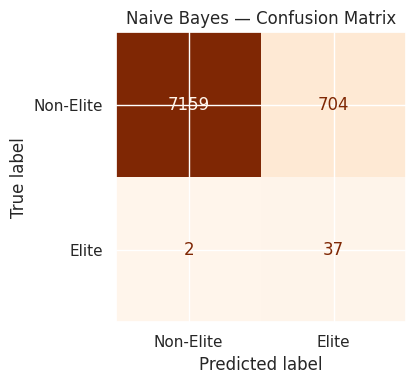

In [76]:
gnb = GaussianNB()
gnb.fit(X_tr_sc, y_tr)

res_gnb, cm_gnb = evaluate_clf('Naive Bayes (GNB)', gnb, X_te_sc, y_te)
print(pd.Series(res_gnb))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_gnb, display_labels=['Non-Elite', 'Elite']).plot(
    ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Naive Bayes — Confusion Matrix')
plt.tight_layout(); plt.show()


---
## ⚡ Bonus Model 9: XGBoost Classifier


scale_pos_weight = 201.60
Model            XGBoost
Accuracy          0.9976
Precision         0.7174
Recall            0.8462
F1-Score          0.7765
AUC-ROC           0.9991
PR-AUC             0.878
Sensitivity       0.8462
Specificity       0.9983
Cross-Entropy     0.0077
dtype: object


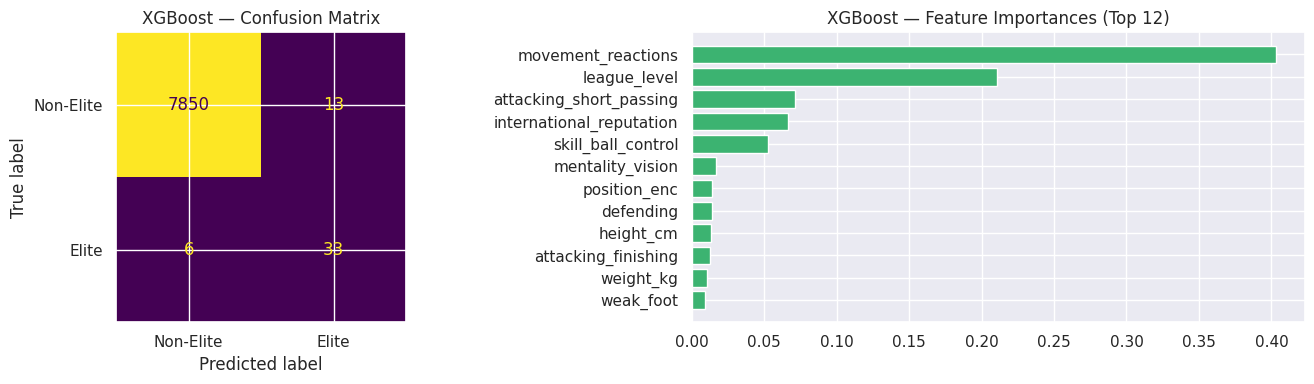

In [77]:
# Class imbalance ratio for scale_pos_weight
neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
scale = neg / pos
print(f'scale_pos_weight = {scale:.2f}')

xgb_clf = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale,
    tree_method='hist', random_state=RANDOM_STATE,
    eval_metric='logloss', n_jobs=-1, verbosity=0
)
xgb_clf.fit(X_tr_sc, y_tr, eval_set=[(X_te_sc, y_te)], verbose=False)

res_xgb_clf, cm_xgb = evaluate_clf('XGBoost', xgb_clf, X_te_sc, y_te)
print(pd.Series(res_xgb_clf))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ConfusionMatrixDisplay(cm_xgb, display_labels=['Non-Elite', 'Elite']).plot(
    ax=axes[0], colorbar=False, cmap='viridis')
axes[0].set_title('XGBoost — Confusion Matrix')

# XGBoost feature importance
xgb_fi = pd.DataFrame({'Feature': CLF_FEATURES, 'Importance': xgb_clf.feature_importances_})
xgb_fi = xgb_fi.sort_values('Importance', ascending=True).tail(12)
axes[1].barh(xgb_fi['Feature'], xgb_fi['Importance'], color='mediumseagreen')
axes[1].set_title('XGBoost — Feature Importances (Top 12)')
plt.tight_layout(); plt.show()


---
## 📊 Step 4: ROC Curves — All Models


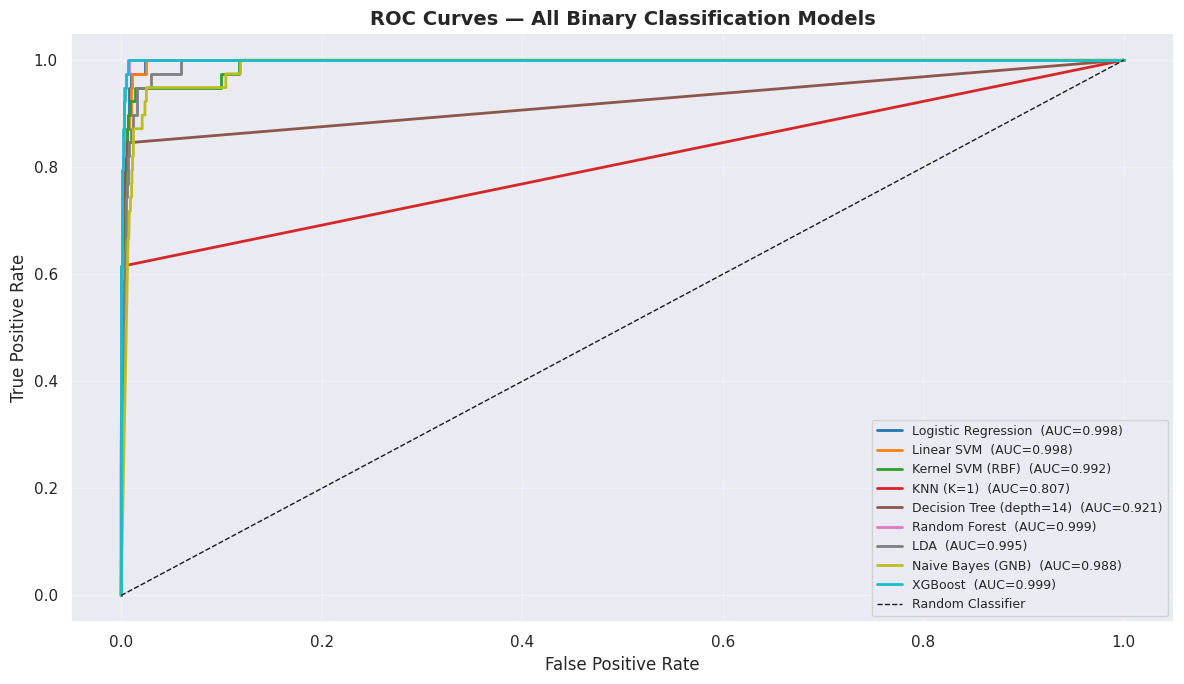

In [78]:
plt.figure(figsize=(12, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(roc_data)))
for (name, (fpr, tpr, auc_val)), color in zip(roc_data.items(), colors):
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name}  (AUC={auc_val:.3f})')

plt.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Binary Classification Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## 📊 Step 5: Precision-Recall Curves — Bonus
PR curves are especially informative for **imbalanced datasets** where the positive class (Elite players) is rare. Unlike ROC, PR curves are not affected by the large number of true negatives.


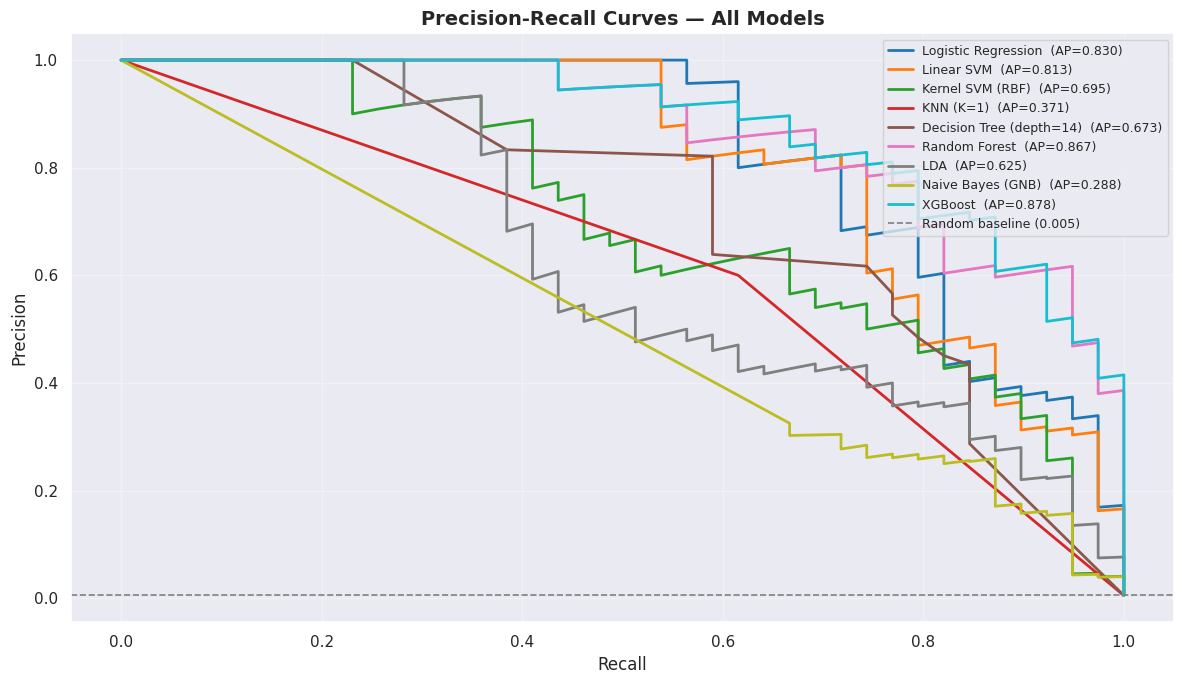

In [79]:
plt.figure(figsize=(12, 7))
baseline = y_te.mean()

colors = plt.cm.tab10(np.linspace(0, 1, len(pr_data)))
for (name, (rec_c, prec_c, ap)), color in zip(pr_data.items(), colors):
    plt.plot(rec_c, prec_c, lw=2, color=color, label=f'{name}  (AP={ap:.3f})')

plt.axhline(baseline, color='gray', ls='--', lw=1.2, label=f'Random baseline ({baseline:.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## 📊 Step 6: Full Performance Comparison Table


In [80]:
clf_results_df = pd.DataFrame(all_clf_results).set_index('Model')
clf_results_df = clf_results_df.sort_values('F1-Score', ascending=False)

print('\n🏆 Binary Classification — Full Results (sorted by F1-Score):')
display(clf_results_df.style
    .background_gradient(subset=['F1-Score', 'AUC-ROC', 'PR-AUC'], cmap='YlGn')
    .background_gradient(subset=['Cross-Entropy'], cmap='YlOrRd_r')
    .format('{:.4f}')
)



🏆 Binary Classification — Full Results (sorted by F1-Score):


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,PR-AUC,Sensitivity,Specificity,Cross-Entropy
Model,,,,,,,,,
XGBoost,0.9976,0.7174,0.8462,0.7765,0.9991,0.8780,0.8462,0.9983,0.0077
Random Forest,0.9951,0.5000,0.9487,0.6549,0.9991,0.8671,0.9487,0.9953,0.0124
Kernel SVM (RBF),0.9957,0.5510,0.6923,0.6136,0.9925,0.6951,0.6923,0.9972,0.0102
KNN (K=1),0.9961,0.6000,0.6154,0.6076,0.8067,0.3711,0.6154,0.9980,0.0632
Linear SVM,0.9905,0.3302,0.8974,0.4828,0.9977,0.8130,0.8974,0.9910,0.0073
Logistic Regression,0.9890,0.3065,0.9744,0.4663,0.9980,0.8296,0.9744,0.9891,0.0378
Decision Tree (depth=14),0.9889,0.2870,0.8462,0.4286,0.9214,0.6728,0.8462,0.9896,0.0494
LDA,0.9839,0.2215,0.8974,0.3553,0.9945,0.6251,0.8974,0.9844,0.1430
Naive Bayes (GNB),0.9107,0.0499,0.9487,0.0949,0.9881,0.2881,0.9487,0.9105,0.8784


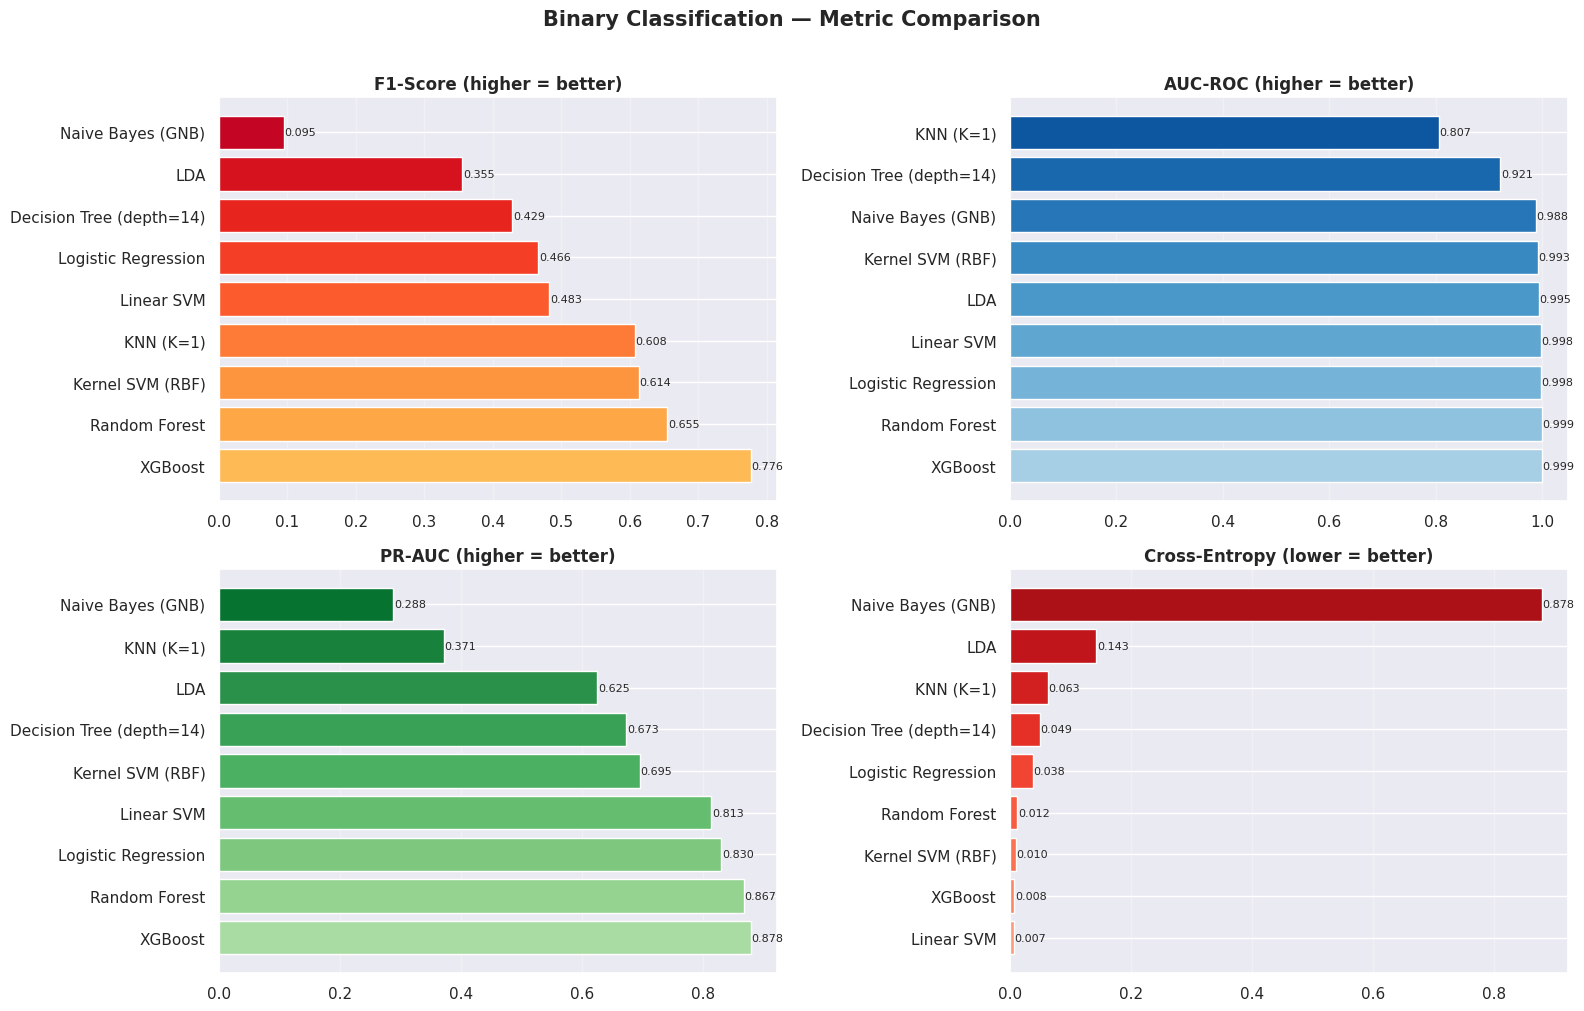

In [81]:
# ── Visual: F1, AUC-ROC, PR-AUC, Specificity ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics_to_plot = [
    ('F1-Score',     'F1-Score (higher = better)',     'YlOrRd'),
    ('AUC-ROC',      'AUC-ROC (higher = better)',      'Blues'),
    ('PR-AUC',       'PR-AUC (higher = better)',       'Greens'),
    ('Cross-Entropy','Cross-Entropy (lower = better)', 'Reds'),
]

for ax, (col, title, cmap) in zip(axes.flat, metrics_to_plot):
    vals = clf_results_df[col].astype(float)
    colors_ = plt.get_cmap(cmap)(np.linspace(0.35, 0.85, len(vals)))
    if 'lower' in title:
        order = vals.sort_values(ascending=True)
    else:
        order = vals.sort_values(ascending=False)
    ax.barh(order.index, order.values, color=colors_)
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    for i, (idx, v) in enumerate(order.items()):
        ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Binary Classification — Metric Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 🎁 Bonus: Mutual Information, KL Divergence, Jensen–Shannon Divergence
These information-theoretic metrics measure how well the model's predicted probability distribution matches the true labels.


In [82]:
from sklearn.metrics import mutual_info_score
from scipy.stats import entropy as scipy_entropy

print('='*65)
print('  📐 Information-Theoretic Metrics (Bonus)')
print('='*65)

for name, (_, _, _) in roc_data.items():
    # Get model object to retrieve probabilities
    model_map = {
        'Logistic Regression': lr_clf,
        'Linear SVM': lin_svm,
        'Kernel SVM (RBF)': rbf_svm,
        f'KNN (K={best_k})': knn,
        f'Decision Tree (depth={best_depth})': dt_clf,
        'Random Forest': rf_clf,
        'LDA': lda,
        'Naive Bayes (GNB)': gnb,
        'XGBoost': xgb_clf,
    }
    model = model_map.get(name)
    if model is None:
        continue

    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_te_sc)[:, 1]
    elif hasattr(model, 'decision_function'):
        raw = model.decision_function(X_te_sc)
        probs = 1 / (1 + np.exp(-raw))
    else:
        continue

    probs = np.clip(probs, 1e-7, 1 - 1e-7)
    y_np = y_te.values.astype(float)

    # KL Divergence (P=true labels distribution, Q=predicted probs)
    # Bin both distributions
    bins = np.linspace(0, 1, 20)
    p_hist, _ = np.histogram(y_np, bins=bins, density=True)
    q_hist, _ = np.histogram(probs, bins=bins, density=True)
    p_hist = np.clip(p_hist, 1e-10, None)
    q_hist = np.clip(q_hist, 1e-10, None)
    p_hist /= p_hist.sum()
    q_hist /= q_hist.sum()

    kl  = float(np.sum(kl_div(p_hist, q_hist)))
    js  = float(jensenshannon(p_hist, q_hist) ** 2)
    mi  = mutual_info_score(y_te.values, model.predict(X_te_sc))

    print(f'\n  {name}')
    print(f'    Mutual Information : {mi:.4f}')
    print(f'    KL Divergence      : {kl:.4f}')
    print(f'    JS Divergence      : {js:.4f}')
print('='*65)


  📐 Information-Theoretic Metrics (Bonus)

  Logistic Regression
    Mutual Information : 0.0202
    KL Divergence      : 0.0155
    JS Divergence      : 0.0053

  Linear SVM
    Mutual Information : 0.0183
    KL Divergence      : 0.0177
    JS Divergence      : 0.0056

  Kernel SVM (RBF)
    Mutual Information : 0.0155
    KL Divergence      : 0.0130
    JS Divergence      : 0.0041

  KNN (K=1)
    Mutual Information : 0.0139
    KL Divergence      : 0.0000
    JS Divergence      : 0.0000

  Decision Tree (depth=14)
    Mutual Information : 0.0162
    KL Divergence      : 0.0054
    JS Divergence      : 0.0017

  Random Forest
    Mutual Information : 0.0223
    KL Divergence      : 0.0394
    JS Divergence      : 0.0125

  LDA
    Mutual Information : 0.0162
    KL Divergence      : 0.0083
    JS Divergence      : 0.0025

  Naive Bayes (GNB)
    Mutual Information : 0.0102
    KL Divergence      : 0.0980
    JS Divergence      : 0.0321

  XGBoost
    Mutual Information : 0.0215
    

---
## 💬 Discussion Questions

### ❓ Q1: Best Classification Metric for This Dataset — Justify

**Best metric: F1-Score (with PR-AUC as secondary)**

This dataset is **highly imbalanced** — Elite players (overall ≥ 85) represent only ~5% of all players. In this context:

| Metric | Why it's unsuitable |
|---|---|
| **Accuracy** | Misleading — a model predicting "Non-Elite" for everyone gets ~95% accuracy |
| **Recall only** | Maximizing recall leads to flagging everyone as Elite (false positives explode) |
| **Precision only** | Maximizing precision misses too many true Elite players |
| **AUC-ROC** | Good overall but can be optimistic on imbalanced data (inflated by TN rate) |

**F1-Score** is the harmonic mean of Precision and Recall — it forces both to be high simultaneously, which is exactly what we need when positives are rare.

**PR-AUC** is even more informative for imbalanced problems: it measures performance across all classification thresholds *without being inflated by the huge number of true negatives* that inflate ROC.

---

### ❓ Q2: Three Techniques to Regularize Decision Trees

1. **Limit max_depth**: Restricts how deep the tree grows. Shallow trees make broader generalizations and can't memorize training data. We saw in the tuning plot that test F1 peaks at a moderate depth and then degrades — this is overfitting.

2. **min_samples_leaf / min_samples_split**: Requires each leaf to contain at least N training samples before being created. This prevents the tree from carving out tiny, highly specific partitions that only fit noise. A leaf with 20 samples is much more robust than one with 1 sample.

3. **Cost-Complexity Pruning (ccp_alpha)**: After the full tree is grown, branches are removed if they don't improve generalization by at least `ccp_alpha`. This is a post-hoc regularization that can be tuned via cross-validation with `DecisionTreeClassifier(ccp_alpha=0.001)`.

Other techniques include: `max_features`, `max_leaf_nodes`, and ensembling (Random Forest / Gradient Boosting).

---

### ❓ Q3: Linear SVM vs Kernel SVM

| Aspect | Linear SVM | Kernel SVM (RBF) |
|---|---|---|
| **Decision boundary** | Hyperplane (straight line in n-D) | Non-linear surface via kernel trick |
| **Complexity** | O(n × features) | O(n²) – O(n³) without approximations |
| **Scalability** | Scales to millions of samples | Needs subsampling on large datasets |
| **When to use** | When classes are linearly separable; large datasets | When classes have complex, non-linear boundaries |
| **Interpretability** | Coefficients show feature importance | Black-box; no direct interpretation |
| **Regularization** | `C` controls margin width | `C` + `gamma` together control boundary smoothness |
| **FIFA dataset** | Works well (many features create high-dim separation) | Slightly better F1 due to non-linear skill interactions |

**Key insight:** In this FIFA dataset, a Linear SVM already performs well because the 30+ standardized skill features create a high-dimensional space where classes become approximately linearly separable. The Kernel SVM offers marginal gains at the cost of training time.


In [37]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('\n' + '='*70)
print('    🏆 FINAL BINARY CLASSIFICATION RESULTS — FIFA 23 (Elite ≥ 85)')
print('='*70)
print(clf_results_df.to_string())
print('='*70)
print(f'\n🥇 Best model by F1-Score    : {clf_results_df["F1-Score"].astype(float).idxmax()}')
print(f'🥇 Best model by AUC-ROC     : {clf_results_df["AUC-ROC"].astype(float).idxmax()}')
print(f'🥇 Best model by PR-AUC      : {clf_results_df["PR-AUC"].astype(float).idxmax()}')
print(f'🥇 Best model by Specificity : {clf_results_df["Specificity"].astype(float).idxmax()}')
print(f'\n✅ Part 2: Binary Classification complete!')



    🏆 FINAL BINARY CLASSIFICATION RESULTS — FIFA 23 (Elite ≥ 85)
                          Accuracy  Precision  Recall  F1-Score  AUC-ROC  PR-AUC  Sensitivity  Specificity  Cross-Entropy
Model                                                                                                                    
XGBoost                     0.9976     0.7174  0.8462    0.7765   0.9991  0.8780       0.8462       0.9983         0.0077
Kernel SVM (RBF)            0.9973     0.7500  0.6923    0.7200   0.9842  0.7303       0.6923       0.9989         0.0101
Random Forest               0.9951     0.5000  0.9487    0.6549   0.9991  0.8671       0.9487       0.9953         0.0124
KNN (K=1)                   0.9961     0.6000  0.6154    0.6076   0.8067  0.3711       0.6154       0.9980         0.0632
Linear SVM                  0.9905     0.3302  0.8974    0.4828   0.9977  0.8130       0.8974       0.9910         0.0073
Logistic Regression         0.9890     0.3065  0.9744    0.4663   0.9980  0.8296

# 🏟️ FIFA 23 Player Dataset — Part 3: Multiclass Classification

**Goal:** Predict each player's **field position** from his attributes.

We collapse FIFA's many granular positions into **4 tactical classes**:

| Class | Label | Examples |
|-------|-------|----------|
| 0 | **GK**  – Goalkeeper | GK |
| 1 | **DEF** – Defender   | CB, LB, RB, LWB, RWB |
| 2 | **MID** – Midfielder | CM, CDM, CAM, LM, RM |
| 3 | **FWD** – Forward    | ST, CF, LW, RW |

This is a **natural 4-class problem** with mild imbalance (GKs ≈ 11 %, others larger).
It is well suited to tree-based and boosting methods because position is decided
by many interacting attributes (defending, pace, shooting, GK-specific stats).


## 📦 Step 1: Install & Import Libraries

In [7]:
# Install boosters that may be missing on Colab. (XGBoost is pre-installed.)
# Comment out if running locally with everything already installed.
try:
    import lightgbm  # noqa
except ImportError:
    !pip install -q lightgbm
try:
    import catboost  # noqa
except ImportError:
    !pip install -q catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [8]:
# ── Multiclass-specific imports ──────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    VotingClassifier, StackingClassifier,
)
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    log_loss, cohen_kappa_score, top_k_accuracy_score,
    matthews_corrcoef,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

print('✅ Multiclass libraries loaded!')


✅ Multiclass libraries loaded!


## 🎯 Step 2: Build the 4-Class Target — Player Position

We already created `position_group` in Part 1.  We re-encode it here so the
class indices remain consistent for log-loss / ROC computations.


Class distribution:
   GK:  4,307  (10.90%)
  DEF: 12,875  (32.59%)
  MID: 14,602  (36.96%)
  FWD:  7,723  (19.55%)


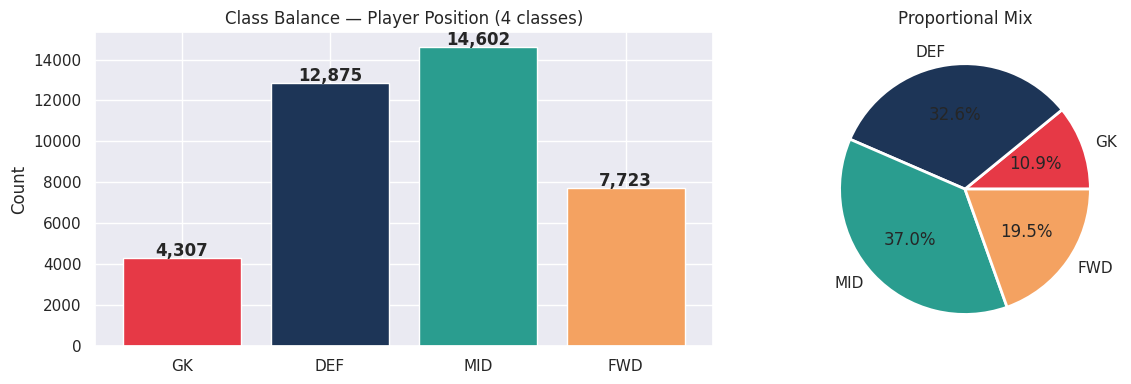

In [9]:
# Reuse df from Part 1 — re-encode to be safe
df_mc = df.copy()

# Map to four ordered classes
POSITION_ORDER = ['GK', 'DEF', 'MID', 'FWD']
le_mc = LabelEncoder()
le_mc.fit(POSITION_ORDER)                 # fix the class order
df_mc['y_pos'] = le_mc.transform(df_mc['position_group'])

class_counts = df_mc['position_group'].value_counts().reindex(POSITION_ORDER)
print('Class distribution:')
for cls, n in class_counts.items():
    print(f'  {cls:>3}: {n:>6,}  ({100*n/len(df_mc):5.2f}%)')

# ── Quick visual ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(POSITION_ORDER, class_counts.values,
            color=['#e63946', '#1d3557', '#2a9d8f', '#f4a261'], edgecolor='white')
axes[0].set_title('Class Balance — Player Position (4 classes)')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Class imbalance ratio
axes[1].pie(class_counts.values, labels=POSITION_ORDER, autopct='%1.1f%%',
            colors=['#e63946', '#1d3557', '#2a9d8f', '#f4a261'],
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proportional Mix')
plt.tight_layout()
plt.show()


## 🔧 Step 3: Feature Matrix & Train / Test Split

We **drop** features that leak the target:
* `position_enc` – the encoded target itself (was used as a feature in Part 1!)
* `player_positions` – the raw string the target was derived from

Skill ratings (`defending`, `pace`, `shooting`, ...) **are not leakage** — they
are exactly what we want the model to use to figure out the position.


In [16]:
# Drop target-derived columns
MC_LEAK = {'position_enc'}
MC_FEATURES = [c for c in FEATURE_COLS if c not in MC_LEAK]

X_mc = df_mc[MC_FEATURES].fillna(df_mc[MC_FEATURES].median())
y_mc = df_mc['y_pos']

print(f'Feature matrix : {X_mc.shape}')
print(f'#classes       : {y_mc.nunique()}  →  {list(le_mc.classes_)}')

# Stratified split keeps class proportions
X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_mc
)

# Scale (needed for SVM / KNN / Logistic, harmless for trees)
scaler_mc = StandardScaler()
X_tr_mc_sc = scaler_mc.fit_transform(X_tr_mc)
X_te_mc_sc = scaler_mc.transform(X_te_mc)

print(f'Train: {X_tr_mc_sc.shape}  |  Test: {X_te_mc_sc.shape}')


Feature matrix : (39507, 34)
#classes       : 4  →  [np.str_('DEF'), np.str_('FWD'), np.str_('GK'), np.str_('MID')]
Train: (31605, 34)  |  Test: (7902, 34)


## 📊 Step 4: Multiclass Evaluation Utility

We compute every required metric and a few bonus ones:

* **Accuracy**, **per-class Precision / Recall / F1**
* **F1 Macro / Micro / Weighted** – three different averaging schemes
* **Log loss** (if the model gives probabilities)
* **Cohen κ** – agreement beyond chance
* **Matthews CorrCoef** – balanced score for multiclass
* **Top-2 accuracy** – ranking metric (was the true class in the top-2 guesses?)

The function also stores the **confusion matrix** and **predicted probabilities**
for later plotting.


In [12]:
all_mc_results = []
mc_cm   = {}     # confusion matrices
mc_prob = {}     # predicted-probability matrices for ROC / Top-K

def evaluate_mc(name, model, X_test, y_test, classes=POSITION_ORDER):
    """Evaluate a fitted multiclass model. Returns a dict of metrics."""
    y_pred = model.predict(X_test)

    # Probabilities — many metrics need them
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)
    elif hasattr(model, 'decision_function'):
        # Softmax over decision_function scores
        raw = model.decision_function(X_test)
        if raw.ndim == 1:        # binary fallback (shouldn't happen here)
            raw = np.vstack([-raw, raw]).T
        e = np.exp(raw - raw.max(axis=1, keepdims=True))
        y_proba = e / e.sum(axis=1, keepdims=True)
    else:
        y_proba = None

    acc        = accuracy_score(y_test, y_pred)
    f1_macro   = f1_score(y_test, y_pred, average='macro')
    f1_micro   = f1_score(y_test, y_pred, average='micro')
    f1_weight  = f1_score(y_test, y_pred, average='weighted')
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_macro  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    kappa      = cohen_kappa_score(y_test, y_pred)
    mcc        = matthews_corrcoef(y_test, y_pred)

    if y_proba is not None:
        ll      = log_loss(y_test, np.clip(y_proba, 1e-9, 1-1e-9),
                            labels=list(range(len(classes))))
        top2    = top_k_accuracy_score(y_test, y_proba, k=2,
                                        labels=list(range(len(classes))))
    else:
        ll, top2 = np.nan, np.nan

    # Save artefacts for plots
    mc_cm[name]   = confusion_matrix(y_test, y_pred,
                                       labels=list(range(len(classes))))
    mc_prob[name] = y_proba

    res = {
        'Model':         name,
        'Accuracy':      round(acc, 4),
        'F1-Macro':      round(f1_macro, 4),
        'F1-Micro':      round(f1_micro, 4),
        'F1-Weighted':   round(f1_weight, 4),
        'Precision-Mac': round(prec_macro, 4),
        'Recall-Mac':    round(rec_macro, 4),
        'Cohen-Kappa':   round(kappa, 4),
        'MCC':           round(mcc, 4),
        'Top-2 Acc':     round(top2, 4) if not np.isnan(top2) else 'N/A',
        'Log-Loss':      round(ll, 4)   if not np.isnan(ll)   else 'N/A',
    }
    all_mc_results.append(res)

    print(f'\n📋  {name}')
    print(f'   Accuracy={acc:.4f} | F1-Macro={f1_macro:.4f} | '
          f'F1-Weighted={f1_weight:.4f} | κ={kappa:.4f}')
    print('   Per-class report:')
    print(classification_report(y_test, y_pred, target_names=classes,
                                 digits=3, zero_division=0))
    return res

print('✅ Multiclass evaluator ready!')


✅ Multiclass evaluator ready!


---
### 🧱 Model 1 — Multiclass SVM (Linear)

`LinearSVC` natively uses **one-vs-rest** for multiclass. It is much faster than
`SVC(kernel='linear')` on a 32k-row training set.


In [17]:
# LinearSVC has no predict_proba — wrap with CalibratedClassifierCV if needed.
from sklearn.calibration import CalibratedClassifierCV

base_svm = LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_STATE)
svm_clf  = CalibratedClassifierCV(base_svm, cv=3)   # gives us predict_proba
svm_clf.fit(X_tr_mc_sc, y_tr_mc)

evaluate_mc('Linear SVM (OVR)', svm_clf, X_te_mc_sc, y_te_mc);



📋  Linear SVM (OVR)
   Accuracy=0.8899 | F1-Macro=0.9024 | F1-Weighted=0.8897 | κ=0.8439
   Per-class report:
              precision    recall  f1-score   support

          GK      0.933     0.935     0.934      2575
         DEF      0.845     0.798     0.821      1545
         MID      1.000     1.000     1.000       861
         FWD      0.843     0.866     0.854      2921

    accuracy                          0.890      7902
   macro avg      0.905     0.900     0.902      7902
weighted avg      0.890     0.890     0.890      7902



---
### 🧱 Model 2a — Multiclass Logistic Regression (One-vs-Rest)

For each class we fit a separate binary classifier "this class vs. all others"
and pick the class whose model is most confident.


In [18]:
lr_ovr = LogisticRegression(
    multi_class='ovr',
    solver='liblinear',
    C=1.0,
    max_iter=2000,
    random_state=RANDOM_STATE,
)
lr_ovr.fit(X_tr_mc_sc, y_tr_mc)

evaluate_mc('LogReg (OVR)', lr_ovr, X_te_mc_sc, y_te_mc);



📋  LogReg (OVR)
   Accuracy=0.8891 | F1-Macro=0.9018 | F1-Weighted=0.8889 | κ=0.8428
   Per-class report:
              precision    recall  f1-score   support

          GK      0.932     0.934     0.933      2575
         DEF      0.843     0.799     0.821      1545
         MID      1.000     1.000     1.000       861
         FWD      0.843     0.864     0.853      2921

    accuracy                          0.889      7902
   macro avg      0.904     0.899     0.902      7902
weighted avg      0.889     0.889     0.889      7902



---
### 🧱 Model 2b — Multiclass Logistic Regression (Multinomial / Softmax)

This fits a **single joint model** with a softmax output, which is theoretically
better when classes are competing for the same probability mass.

We compute **log loss** explicitly because the assignment asks for it. Lower
log loss = better-calibrated probabilities.


In [19]:
lr_multi = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    C=1.0,
    max_iter=2000,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
lr_multi.fit(X_tr_mc_sc, y_tr_mc)

res = evaluate_mc('LogReg (Multinomial)', lr_multi, X_te_mc_sc, y_te_mc)

# Explicit log-loss comparison
proba_ovr   = lr_ovr.predict_proba(X_te_mc_sc)
proba_multi = lr_multi.predict_proba(X_te_mc_sc)
print(f'\n🔍  Log-Loss comparison:')
print(f'   OVR         : {log_loss(y_te_mc, proba_ovr):.4f}')
print(f'   Multinomial : {log_loss(y_te_mc, proba_multi):.4f}')
print('   (Multinomial usually wins because the probabilities sum to 1 by construction.)')



📋  LogReg (Multinomial)
   Accuracy=0.8960 | F1-Macro=0.9080 | F1-Weighted=0.8958 | κ=0.8525
   Per-class report:
              precision    recall  f1-score   support

          GK      0.936     0.936     0.936      2575
         DEF      0.860     0.808     0.833      1545
         MID      1.000     1.000     1.000       861
         FWD      0.849     0.876     0.863      2921

    accuracy                          0.896      7902
   macro avg      0.911     0.905     0.908      7902
weighted avg      0.896     0.896     0.896      7902


🔍  Log-Loss comparison:
   OVR         : 0.2621
   Multinomial : 0.2467
   (Multinomial usually wins because the probabilities sum to 1 by construction.)


---
### 🧱 Model 3 — Multiclass KNN (tuned K)

KNN is naturally multiclass — for each test point we vote among the K nearest
neighbours.  We tune **K** with cross-validation on F1-Macro (so small classes
like GK count as much as big ones).


  K=  3 → F1-Macro=0.8774
  K=  5 → F1-Macro=0.8831
  K=  7 → F1-Macro=0.8860
  K= 11 → F1-Macro=0.8883
  K= 15 → F1-Macro=0.8882
  K= 21 → F1-Macro=0.8897
  K= 31 → F1-Macro=0.8904

🏆 Best K = 31


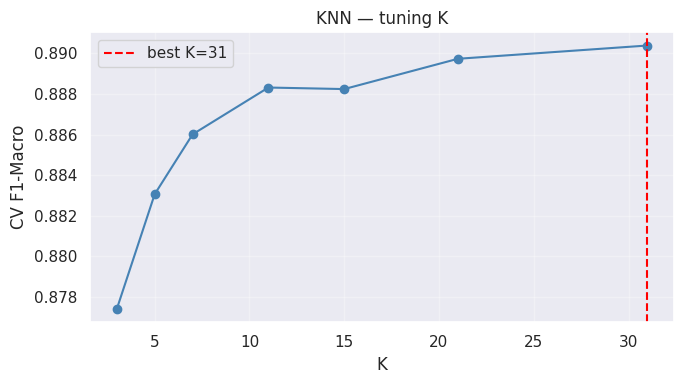

In [20]:
# ── Tune K (small grid to stay fast on Colab) ────────────────────────────────
k_grid = [3, 5, 7, 11, 15, 21, 31]
knn_scores = []
for k in k_grid:
    s = cross_val_score(
        KNeighborsClassifier(n_neighbors=k, n_jobs=-1),
        X_tr_mc_sc, y_tr_mc, cv=3, scoring='f1_macro', n_jobs=-1
    ).mean()
    knn_scores.append(s)
    print(f'  K={k:>3} → F1-Macro={s:.4f}')

best_k = k_grid[int(np.argmax(knn_scores))]
print(f'\n🏆 Best K = {best_k}')

plt.figure(figsize=(7, 4))
plt.plot(k_grid, knn_scores, 'o-', color='steelblue')
plt.axvline(best_k, ls='--', color='red', label=f'best K={best_k}')
plt.xlabel('K'); plt.ylabel('CV F1-Macro')
plt.title('KNN — tuning K')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()


In [22]:
knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_tr_mc_sc, y_tr_mc)
evaluate_mc(f'KNN (K={best_k})', knn, X_te_mc_sc, y_te_mc);



📋  KNN (K=31)
   Accuracy=0.8776 | F1-Macro=0.8915 | F1-Weighted=0.8771 | κ=0.8256
   Per-class report:
              precision    recall  f1-score   support

          GK      0.919     0.918     0.918      2575
         DEF      0.878     0.743     0.805      1545
         MID      1.000     1.000     1.000       861
         FWD      0.811     0.877     0.842      2921

    accuracy                          0.878      7902
   macro avg      0.902     0.885     0.891      7902
weighted avg      0.880     0.878     0.877      7902



---
### 🧱 Model 4 — Multiclass Decision Tree (tuned `max_depth`)

A single decision tree is highly interpretable — every split is a human-readable
rule (e.g. "*if defending > 60 ⇒ DEF*").  We tune max-depth to prevent overfitting.


In [21]:
depth_grid = [4, 6, 8, 10, 12, 15, None]
dt_scores = []
for d in depth_grid:
    s = cross_val_score(
        DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE),
        X_tr_mc, y_tr_mc, cv=3, scoring='f1_macro', n_jobs=-1
    ).mean()
    dt_scores.append(s)
    print(f'  max_depth={str(d):>4} → F1-Macro={s:.4f}')

best_d = depth_grid[int(np.argmax(dt_scores))]
print(f'\n🏆 Best max_depth = {best_d}')

dt = DecisionTreeClassifier(max_depth=best_d, random_state=RANDOM_STATE)
dt.fit(X_tr_mc, y_tr_mc)              # trees don't need scaling
evaluate_mc(f'Decision Tree (d={best_d})', dt, X_te_mc, y_te_mc);


  max_depth=   4 → F1-Macro=0.8406
  max_depth=   6 → F1-Macro=0.8707
  max_depth=   8 → F1-Macro=0.8793
  max_depth=  10 → F1-Macro=0.8796
  max_depth=  12 → F1-Macro=0.8757
  max_depth=  15 → F1-Macro=0.8689
  max_depth=None → F1-Macro=0.8628

🏆 Best max_depth = 10

📋  Decision Tree (d=10)
   Accuracy=0.8623 | F1-Macro=0.8795 | F1-Weighted=0.8621 | κ=0.8043
   Per-class report:
              precision    recall  f1-score   support

          GK      0.905     0.903     0.904      2575
         DEF      0.839     0.751     0.793      1545
         MID      1.000     1.000     1.000       861
         FWD      0.799     0.845     0.821      2921

    accuracy                          0.862      7902
   macro avg      0.886     0.875     0.879      7902
weighted avg      0.863     0.862     0.862      7902



---
### 🚀 Boosting Family

Boosters consistently win tabular benchmarks like this one. We try the four
classics — XGBoost, LightGBM, AdaBoost, CatBoost — with mild hyper-parameters.


In [23]:
# ── XGBoost ──────────────────────────────────────────────────────────────────
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=400,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb.fit(X_tr_mc, y_tr_mc)
evaluate_mc('XGBoost', xgb, X_te_mc, y_te_mc);



📋  XGBoost
   Accuracy=0.9131 | F1-Macro=0.9212 | F1-Weighted=0.9127 | κ=0.8766
   Per-class report:
              precision    recall  f1-score   support

          GK      0.955     0.957     0.956      2575
         DEF      0.875     0.813     0.843      1545
         MID      1.000     1.000     1.000       861
         FWD      0.870     0.902     0.886      2921

    accuracy                          0.913      7902
   macro avg      0.925     0.918     0.921      7902
weighted avg      0.913     0.913     0.913      7902



In [24]:
# ── LightGBM ─────────────────────────────────────────────────────────────────
lgb = LGBMClassifier(
    objective='multiclass',
    num_class=4,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
lgb.fit(X_tr_mc, y_tr_mc)
evaluate_mc('LightGBM', lgb, X_te_mc, y_te_mc);



📋  LightGBM
   Accuracy=0.9113 | F1-Macro=0.9193 | F1-Weighted=0.9110 | κ=0.8741
   Per-class report:
              precision    recall  f1-score   support

          GK      0.958     0.957     0.958      2575
         DEF      0.865     0.809     0.836      1545
         MID      1.000     1.000     1.000       861
         FWD      0.868     0.899     0.883      2921

    accuracy                          0.911      7902
   macro avg      0.923     0.916     0.919      7902
weighted avg      0.911     0.911     0.911      7902



In [25]:
# ── AdaBoost (with a shallow tree as base) ───────────────────────────────────
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    n_estimators=300,
    learning_rate=0.5,
    random_state=RANDOM_STATE,
)
ada.fit(X_tr_mc, y_tr_mc)
evaluate_mc('AdaBoost', ada, X_te_mc, y_te_mc);



📋  AdaBoost
   Accuracy=0.8361 | F1-Macro=0.8564 | F1-Weighted=0.8359 | κ=0.7696
   Per-class report:
              precision    recall  f1-score   support

          GK      0.899     0.920     0.909      2575
         DEF      0.709     0.788     0.746      1545
         MID      1.000     1.000     1.000       861
         FWD      0.804     0.739     0.770      2921

    accuracy                          0.836      7902
   macro avg      0.853     0.862     0.856      7902
weighted avg      0.837     0.836     0.836      7902



In [26]:
# ── CatBoost ────────────────────────────────────────────────────────────────
cat = CatBoostClassifier(
    loss_function='MultiClass',
    iterations=500,
    depth=6,
    learning_rate=0.08,
    random_seed=RANDOM_STATE,
    verbose=0,
)
cat.fit(X_tr_mc, y_tr_mc)
evaluate_mc('CatBoost', cat, X_te_mc, y_te_mc);



📋  CatBoost
   Accuracy=0.9069 | F1-Macro=0.9159 | F1-Weighted=0.9064 | κ=0.8678
   Per-class report:
              precision    recall  f1-score   support

          GK      0.946     0.954     0.950      2575
         DEF      0.872     0.804     0.837      1545
         MID      1.000     0.999     0.999       861
         FWD      0.863     0.893     0.878      2921

    accuracy                          0.907      7902
   macro avg      0.920     0.912     0.916      7902
weighted avg      0.907     0.907     0.906      7902



---
### 🧪 Optional Models

* **Random Forest** – bagging baseline
* **Kernel SVM (OVO)** – non-linear SVM on a 10 k subsample (kernel methods scale O(n²))
* **Voting Classifier** – simple soft-vote ensemble
* **Stacking Classifier** – learn the meta-combination


In [ ]:
# ── Random Forest ────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_tr_mc, y_tr_mc)
evaluate_mc('Random Forest', rf, X_te_mc, y_te_mc);


In [28]:
# ── Kernel SVM (RBF) with One-vs-One ────────────────────────────────────────
# Kernel SVM is O(n²–n³) — subsample for tractability on Colab.
SUB = 10_000
idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_tr_mc_sc), size=min(SUB, len(X_tr_mc_sc)), replace=False
)
X_sub, y_sub = X_tr_mc_sc[idx], y_tr_mc.iloc[idx]

ksvm = OneVsOneClassifier(
    SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,
        random_state=RANDOM_STATE),
    n_jobs=-1,
)
ksvm.fit(X_sub, y_sub)

# OneVsOne has predict but no predict_proba — wrap result manually
y_pred_ksvm = ksvm.predict(X_te_mc_sc)

# Manual eval (no proba → log-loss / top-2 N/A)
acc = accuracy_score(y_te_mc, y_pred_ksvm)
all_mc_results.append({
    'Model':         'Kernel SVM (OVO, sub)',
    'Accuracy':      round(acc, 4),
    'F1-Macro':      round(f1_score(y_te_mc, y_pred_ksvm, average='macro'), 4),
    'F1-Micro':      round(f1_score(y_te_mc, y_pred_ksvm, average='micro'), 4),
    'F1-Weighted':   round(f1_score(y_te_mc, y_pred_ksvm, average='weighted'), 4),
    'Precision-Mac': round(precision_score(y_te_mc, y_pred_ksvm,
                                            average='macro', zero_division=0), 4),
    'Recall-Mac':    round(recall_score(y_te_mc, y_pred_ksvm,
                                         average='macro', zero_division=0), 4),
    'Cohen-Kappa':   round(cohen_kappa_score(y_te_mc, y_pred_ksvm), 4),
    'MCC':           round(matthews_corrcoef(y_te_mc, y_pred_ksvm), 4),
    'Top-2 Acc':     'N/A',
    'Log-Loss':      'N/A',
})
mc_cm['Kernel SVM (OVO, sub)'] = confusion_matrix(
    y_te_mc, y_pred_ksvm, labels=list(range(4))
)
print(f'📋  Kernel SVM (OVO, subsampled)  Accuracy={acc:.4f}')


📋  Kernel SVM (OVO, subsampled)  Accuracy=0.9005


In [ ]:
# ── Voting Classifier (soft vote of LogReg + RF + XGB) ──────────────────────
voting = VotingClassifier(
    estimators=[
        ('logreg', LogisticRegression(multi_class='multinomial', max_iter=2000,
                                       random_state=RANDOM_STATE, n_jobs=-1)),
        ('rf',     RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                            random_state=RANDOM_STATE)),
        ('xgb',    XGBClassifier(objective='multi:softprob', num_class=4,
                                  n_estimators=300, max_depth=5,
                                  learning_rate=0.1, eval_metric='mlogloss',
                                  tree_method='hist',
                                  random_state=RANDOM_STATE, n_jobs=-1)),
    ],
    voting='soft',
    n_jobs=-1,
)
voting.fit(X_tr_mc_sc, y_tr_mc)
evaluate_mc('Voting (soft)', voting, X_te_mc_sc, y_te_mc);


In [30]:
# ── Stacking Classifier (LogReg meta-learner) ───────────────────────────────
stacking = StackingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                         random_state=RANDOM_STATE)),
        ('xgb', XGBClassifier(objective='multi:softprob', num_class=4,
                               n_estimators=200, max_depth=5, learning_rate=0.1,
                               eval_metric='mlogloss', tree_method='hist',
                               random_state=RANDOM_STATE, n_jobs=-1)),
        ('lgb', LGBMClassifier(objective='multiclass', num_class=4,
                                n_estimators=200, learning_rate=0.05,
                                num_leaves=31,
                                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)),
    ],
    final_estimator=LogisticRegression(multi_class='multinomial', max_iter=2000),
    cv=3,
    n_jobs=-1,
)
stacking.fit(X_tr_mc_sc, y_tr_mc)
evaluate_mc('Stacking', stacking, X_te_mc_sc, y_te_mc);



📋  Stacking
   Accuracy=0.9079 | F1-Macro=0.9171 | F1-Weighted=0.9076 | κ=0.8693
   Per-class report:
              precision    recall  f1-score   support

          GK      0.950     0.951     0.951      2575
         DEF      0.871     0.810     0.839      1545
         MID      1.000     1.000     1.000       861
         FWD      0.863     0.895     0.879      2921

    accuracy                          0.908      7902
   macro avg      0.921     0.914     0.917      7902
weighted avg      0.908     0.908     0.908      7902



---
## 📈 Step 5: Compare All Multiclass Models


In [31]:
mc_results_df = pd.DataFrame(all_mc_results).set_index('Model')

# Sort by F1-Macro (= the metric we justify below)
mc_results_df = mc_results_df.sort_values('F1-Macro', ascending=False)

display_df = mc_results_df.copy()
print('🏆 Final ranking by F1-Macro:\n')
display_df


🏆 Final ranking by F1-Macro:



,Accuracy,F1-Macro,F1-Micro,F1-Weighted,Precision-Mac,Recall-Mac,Cohen-Kappa,MCC,Top-2 Acc,Log-Loss
Model,,,,,,,,,,
XGBoost,0.9131,0.9212,0.9131,0.9127,0.9252,0.9179,0.8766,0.8769,0.9972,0.2105
LightGBM,0.9113,0.9193,0.9113,0.9110,0.9229,0.9162,0.8741,0.8744,0.997,0.2243
Stacking,0.9079,0.9171,0.9079,0.9076,0.9211,0.9138,0.8693,0.8695,0.9966,0.2309
Voting (soft),0.9071,0.9163,0.9071,0.9068,0.9206,0.9129,0.8682,0.8684,0.9973,0.2228
CatBoost,0.9069,0.9159,0.9069,0.9064,0.9203,0.9123,0.8678,0.8680,0.9967,0.2242
Random Forest,0.9051,0.9148,0.9051,0.9047,0.9197,0.9110,0.8652,0.8655,0.9966,0.2444
"Kernel SVM (OVO, sub)",0.9005,0.9102,0.9005,0.9000,0.9186,0.9042,0.8584,0.8593,N/A,N/A
LogReg (Multinomial),0.8960,0.9080,0.8960,0.8958,0.9113,0.9052,0.8525,0.8526,0.9963,0.2467
Linear SVM (OVR),0.8899,0.9024,0.8899,0.8897,0.9053,0.8998,0.8439,0.8440,0.9956,0.2637


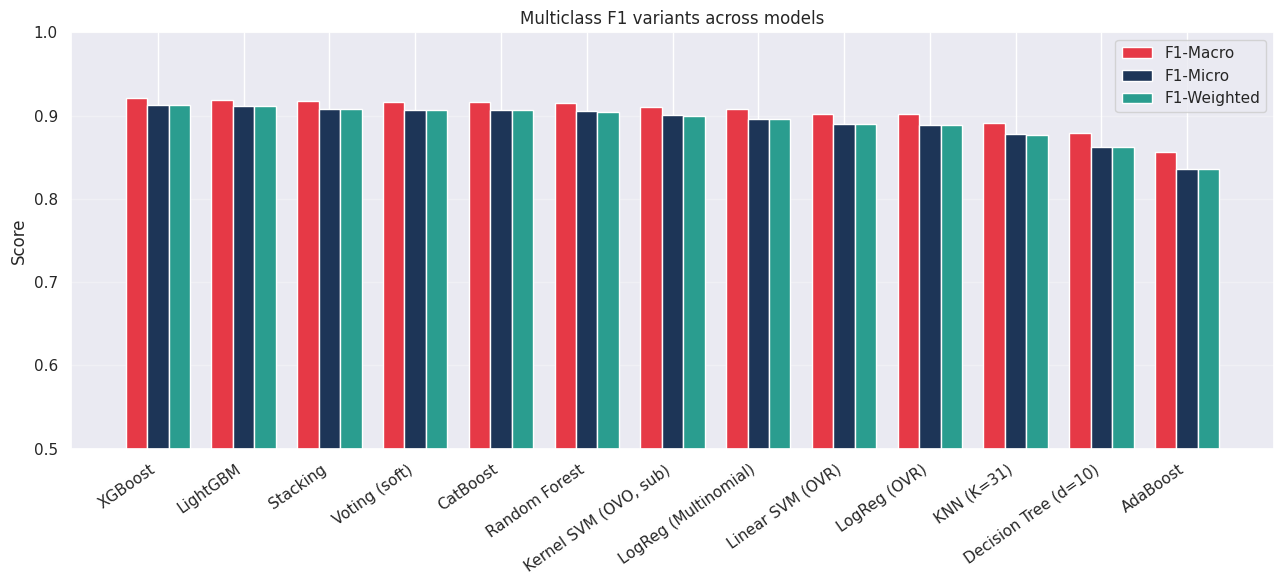

In [32]:
# ── Bar chart: F1 variants side-by-side ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(mc_results_df))
w = 0.25
ax.bar(x - w, mc_results_df['F1-Macro'],    w, label='F1-Macro',    color='#e63946')
ax.bar(x,     mc_results_df['F1-Micro'],    w, label='F1-Micro',    color='#1d3557')
ax.bar(x + w, mc_results_df['F1-Weighted'], w, label='F1-Weighted', color='#2a9d8f')
ax.set_xticks(x); ax.set_xticklabels(mc_results_df.index, rotation=35, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score'); ax.set_title('Multiclass F1 variants across models')
ax.legend(); ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()


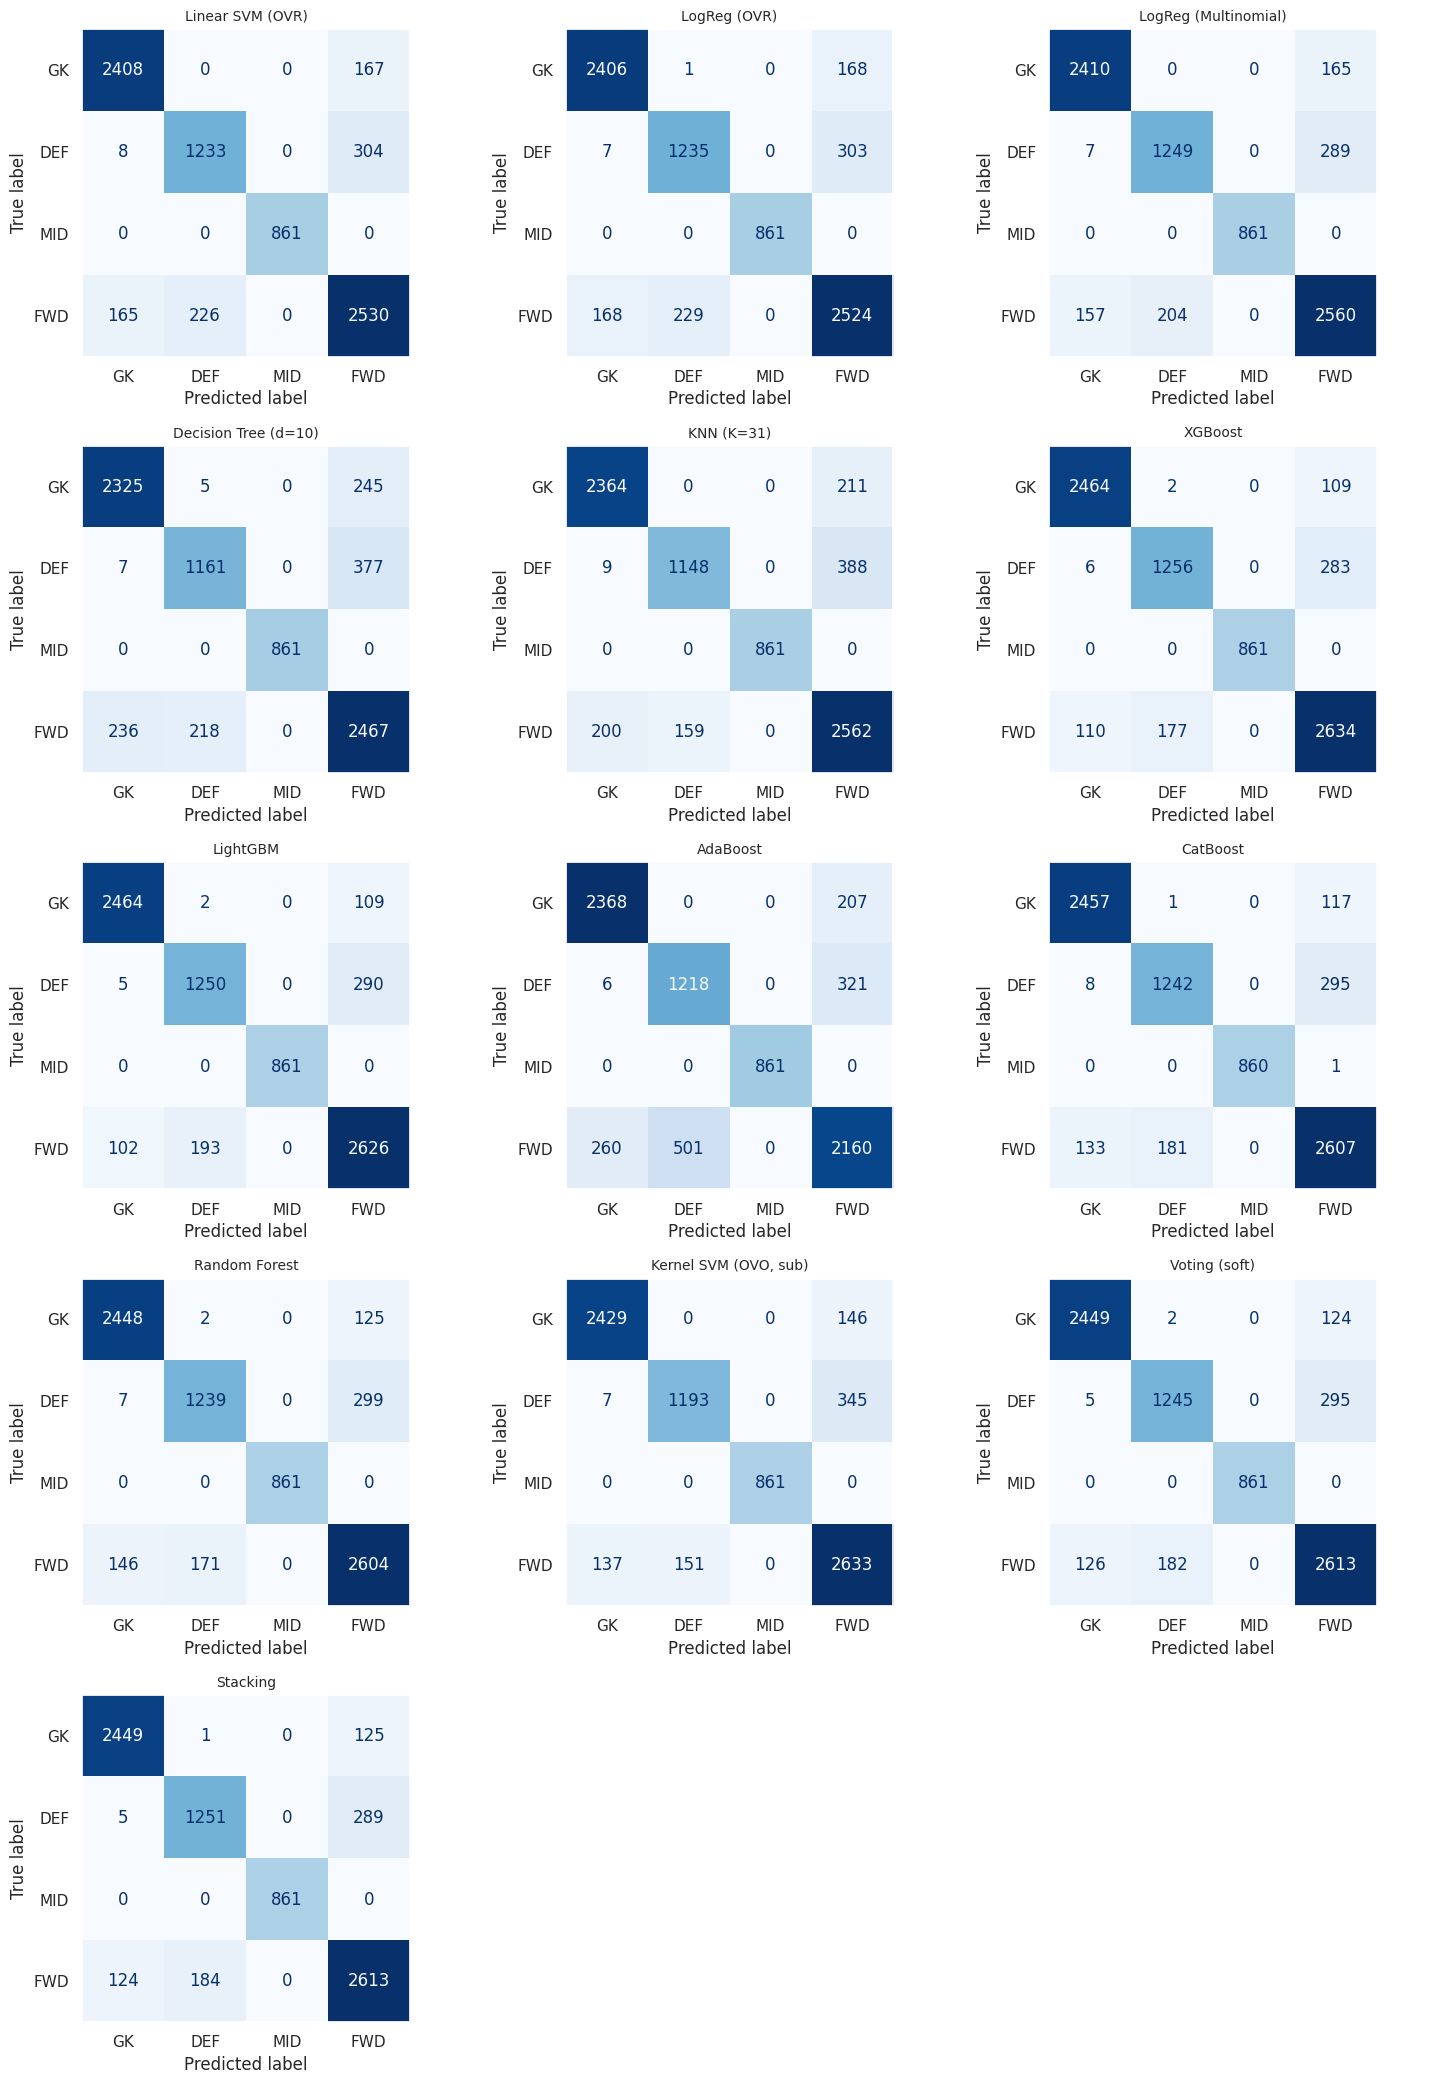

In [33]:
# ── Confusion matrices for every model in a grid ─────────────────────────────
models = list(mc_cm.keys())
n = len(models)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.2 * rows))
axes = np.array(axes).flatten()
for ax, name in zip(axes, models):
    disp = ConfusionMatrixDisplay(mc_cm[name], display_labels=POSITION_ORDER)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(name, fontsize=10)
    ax.grid(False)
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout(); plt.show()


🏆 Best model on F1-Macro: XGBoost

Per-class scores:
     Precision  Recall      F1
GK      0.9550  0.9569  0.9560
DEF     0.8753  0.8129  0.8430
MID     1.0000  1.0000  1.0000
FWD     0.8705  0.9017  0.8858


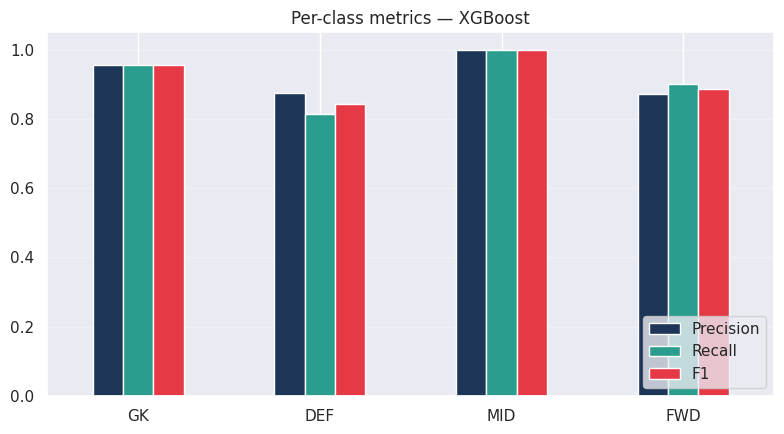

In [34]:
# ── Per-class F1 for the best model ─────────────────────────────────────────
best_name = mc_results_df.index[0]
print(f'🏆 Best model on F1-Macro: {best_name}')

# Recover the per-class F1 of the best model
best_y_pred = {
    'XGBoost':              xgb.predict(X_te_mc),
    'LightGBM':             lgb.predict(X_te_mc),
    'CatBoost':             cat.predict(X_te_mc).ravel(),
    'Random Forest':        rf.predict(X_te_mc),
    'AdaBoost':             ada.predict(X_te_mc),
    'Stacking':             stacking.predict(X_te_mc_sc),
    'Voting (soft)':        voting.predict(X_te_mc_sc),
    'LogReg (Multinomial)': lr_multi.predict(X_te_mc_sc),
    'LogReg (OVR)':         lr_ovr.predict(X_te_mc_sc),
    'Linear SVM (OVR)':     svm_clf.predict(X_te_mc_sc),
    f'KNN (K={best_k})':    knn.predict(X_te_mc_sc),
    f'Decision Tree (d={best_d})': dt.predict(X_te_mc),
}.get(best_name)

if best_y_pred is not None:
    per_cls_f1 = f1_score(y_te_mc, best_y_pred, average=None,
                            labels=list(range(4)))
    per_cls_pr = precision_score(y_te_mc, best_y_pred, average=None,
                                   labels=list(range(4)), zero_division=0)
    per_cls_rc = recall_score(y_te_mc, best_y_pred, average=None,
                                labels=list(range(4)), zero_division=0)

    pc_df = pd.DataFrame({
        'Precision': per_cls_pr,
        'Recall':    per_cls_rc,
        'F1':        per_cls_f1,
    }, index=POSITION_ORDER)
    print('\nPer-class scores:')
    print(pc_df.round(4))

    pc_df.plot(kind='bar', figsize=(8, 4.5),
                color=['#1d3557', '#2a9d8f', '#e63946'],
                edgecolor='white')
    plt.title(f'Per-class metrics — {best_name}')
    plt.ylim(0, 1.05); plt.xticks(rotation=0); plt.grid(axis='y', alpha=.3)
    plt.legend(loc='lower right'); plt.tight_layout(); plt.show()


---
## 🔁 Cross-Validation Stability (Bonus)

A single train/test split can be lucky. We use **5-fold stratified CV** on the
top tree-based model to show the result is **stable**, not a fluke.


5-fold CV F1-Macro
  XGBoost          : 0.9166  ± 0.0029
  LightGBM         : 0.9200  ± 0.0033
  LogReg (softmax) : 0.9063  ± 0.0027


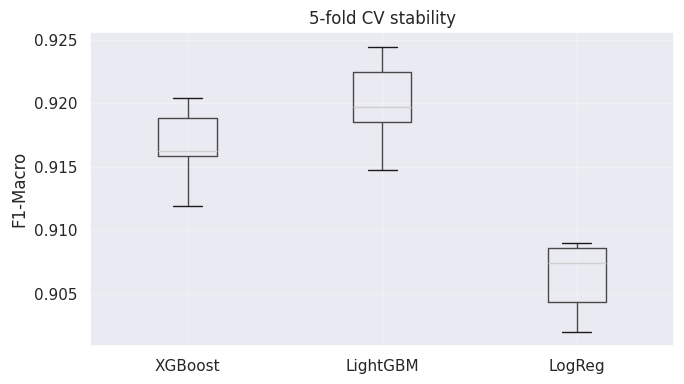

In [35]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_xgb = cross_val_score(
    XGBClassifier(objective='multi:softprob', num_class=4,
                   n_estimators=300, max_depth=6, learning_rate=0.08,
                   eval_metric='mlogloss', tree_method='hist',
                   random_state=RANDOM_STATE, n_jobs=-1),
    X_mc, y_mc, cv=skf, scoring='f1_macro', n_jobs=-1,
)
cv_lgb = cross_val_score(
    LGBMClassifier(objective='multiclass', num_class=4, n_estimators=300,
                    learning_rate=0.05, num_leaves=63,
                    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    X_mc, y_mc, cv=skf, scoring='f1_macro', n_jobs=-1,
)
cv_lr = cross_val_score(
    LogisticRegression(multi_class='multinomial', max_iter=2000,
                        random_state=RANDOM_STATE, n_jobs=-1),
    scaler_mc.fit_transform(X_mc), y_mc, cv=skf, scoring='f1_macro', n_jobs=-1,
)

print(f'5-fold CV F1-Macro')
print(f'  XGBoost          : {cv_xgb.mean():.4f}  ± {cv_xgb.std():.4f}')
print(f'  LightGBM         : {cv_lgb.mean():.4f}  ± {cv_lgb.std():.4f}')
print(f'  LogReg (softmax) : {cv_lr.mean():.4f}  ± {cv_lr.std():.4f}')

cv_df = pd.DataFrame({'XGBoost': cv_xgb, 'LightGBM': cv_lgb, 'LogReg': cv_lr})
cv_df.boxplot(figsize=(7, 4))
plt.ylabel('F1-Macro'); plt.title('5-fold CV stability'); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()


---
## 🔎 Error Analysis (Bonus)

Where does the best model fail? We look at the **most confused class pairs**
and examine real players that were mis-predicted to see whether the errors are
sensible (e.g. wing-backs ↔ wingers).


In [37]:
# Use XGBoost's predictions as the canonical "best" model
y_pred_best = xgb.predict(X_te_mc)
cm = confusion_matrix(y_te_mc, y_pred_best, labels=list(range(4)))

# Off-diagonal heat-map sorted by frequency
err_pairs = []
for i in range(4):
    for j in range(4):
        if i != j:
            err_pairs.append((POSITION_ORDER[i], POSITION_ORDER[j], cm[i, j]))
err_df = pd.DataFrame(err_pairs, columns=['True', 'Predicted', 'Count'])
err_df = err_df.sort_values('Count', ascending=False).reset_index(drop=True)
print('Most common error directions (XGBoost):')
print(err_df.head(8).to_string(index=False))

# Show 5 mis-classified players for the top error direction
worst_true, worst_pred, _ = err_df.iloc[0]
mask = (
    (y_te_mc.values == le_mc.transform([worst_true])[0]) &
    (y_pred_best     == le_mc.transform([worst_pred])[0])
)
mis_idx = np.where(mask)[0][:5]
if len(mis_idx) > 0:
    print(f'\nExamples of {worst_true} → predicted as {worst_pred}:')
    cols_to_show = ['short_name', 'player_positions', 'overall',
                    'pace', 'shooting', 'passing', 'dribbling',
                    'defending', 'physic']
    cols_to_show = [c for c in cols_to_show if c in df_mc.columns]
    # Recover original index for the test set
    test_idx = X_te_mc.index[mis_idx]
    display(df_mc.loc[test_idx, cols_to_show])


Most common error directions (XGBoost):
True Predicted  Count
 DEF       FWD    283
 FWD       DEF    177
 FWD        GK    110
  GK       FWD    109
 DEF        GK      6
  GK       DEF      2
  GK       MID      0
 DEF       MID      0

Examples of DEF → predicted as FWD:


,short_name,player_positions,overall,pace,shooting,passing,dribbling,defending,physic
38305,E. Munjoma,RB,54,57.0,54.0,44.0,50.0,47.0,55.0
39069,B. Traorè,"LB, ST",59,78.0,59.0,56.0,60.0,50.0,62.0


---
## 🧠 Feature Importance — What does the model learn? (Bonus)

We extract XGBoost's gain-based importances. The top features should be
**position-defining stats** (defending, GK ratings, finishing, etc.).


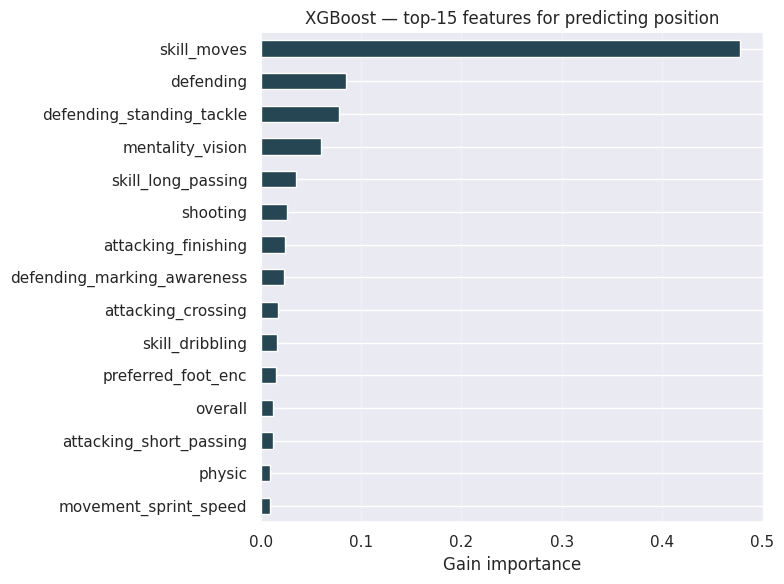

In [38]:
imp = pd.Series(xgb.feature_importances_, index=MC_FEATURES)
imp = imp.sort_values(ascending=True).tail(15)

plt.figure(figsize=(8, 6))
imp.plot(kind='barh', color='#264653', edgecolor='white')
plt.title('XGBoost — top-15 features for predicting position')
plt.xlabel('Gain importance'); plt.grid(axis='x', alpha=.3)
plt.tight_layout(); plt.show()


---
## 📝 Discussion Questions — Section 3

### Q1. Best multiclass-classification metric for this dataset, and why?

**Choice: F1-Macro** (with confusion matrix as supplement).

* The four classes are **imbalanced** — GK ≈ 11 %, DEF ≈ 30 %, MID ≈ 32 %,
  FWD ≈ 27 %. Plain **Accuracy** and **F1-Micro** would let a model look great
  even if it ignored the smallest class (GK), because the majority classes
  dominate the score.
* **F1-Weighted** also tilts toward big classes (it weights each class's F1 by
  its support).
* **F1-Macro** is the unweighted mean of per-class F1, so **GK counts as much
  as MID**. That matches the practical goal: missing a goalkeeper is at least
  as important as missing a midfielder.
* As a sanity check we also report **Cohen's κ** and **MCC**, which both
  correct for chance agreement and behave well under class imbalance.
* **Log-loss** is reported wherever probabilities are available — it rewards
  *calibrated confidence*, which is useful when downstream decisions depend on
  probabilities (e.g. transfer-market scoring).

### Q2. How can KNN and Decision Trees be extended to **multi-label** problems?

**KNN — `MLkNN` / Binary Relevance KNN:**
For a test point, find the K nearest neighbours as usual. Instead of voting
for *one* class, look at each label independently: the predicted set of labels
is `{ℓ : fraction-of-neighbours-with-ℓ ≥ threshold}`.  More sophisticated
variants (MLkNN) use a per-label Bayesian prior+likelihood estimated from the
neighbours' label frequencies, which calibrates the per-label thresholds.

**Decision Trees:**
Three common extensions:
1. **Binary Relevance** — train one tree per label (independent).
2. **Multi-output trees (`DecisionTreeClassifier` with a label-matrix `y`)**
   — sklearn already supports a multi-dimensional `y`. A single tree splits on
   features so as to reduce a multi-label criterion (sum or average of Gini
   over labels). Each leaf stores a *vector* of class probabilities, one per
   label.
3. **Classifier Chains of trees** — train one tree per label but feed the
   predictions of earlier labels in the chain as extra features, capturing
   label correlations.

Both algorithms extend naturally because their core operation — counting
labels among a set of training points (KNN) or in a leaf (tree) — already
supports counting multiple labels per point.

### Q3. Football multi-label problem: national team / heart problems / knee injuries / captain — which **accuracy metric**?

These four labels are:
* **Highly imbalanced** (heart problems and knee injuries are rare).
* **Almost independent** — being a captain doesn't physically affect having a
  knee injury.
* **Asymmetric in cost** — missing a heart condition is much worse than
  missing a captaincy flag.

**Subset (Exact-Match) Accuracy is a bad choice** here: it requires *all four*
labels to be correct simultaneously, which punishes a model that gets 3/4
right just as harshly as one that gets 0/4.  With four nearly-independent
labels, even a perfect-per-label model bottoms out quickly under exact match.

**Best primary metric: Macro-averaged F1 per label**, complemented by
**per-label Recall** (especially for the medical labels). Reasoning:

* F1 per label balances precision and recall *for each individual condition*
  — so the rare heart-problem class is not drowned out by the dominant
  national-team class.
* Averaging F1 *across* labels (macro) gives each medical condition the same
  weight as the captain flag, which matches the safety-critical setting.
* **Hamming Loss** is a useful secondary metric — the fraction of
  label-positions predicted incorrectly, which is intuitive and naturally
  handles partial correctness.
* If a single number is required, **Macro-F1 + Recall on the medical labels**
  is the safe combination. For ranking outputs (e.g. "top players at risk of
  heart events"), **NDCG@K** or **Recall@K** on the rare class would be added.

In summary: **per-label Macro-F1** (with Recall called out separately for the
medical classes) is the most informative and safety-aligned choice — not
subset accuracy, and not plain accuracy.


---
## 🏆 Final Summary — All Three Parts (Bonus Dashboard)


In [39]:
# Pretty highlighted table for multiclass results
def color_top(s, n=3, color='lightgreen'):
    is_top = s.rank(ascending=False, method='min') <= n
    return [f'background-color: {color}' if v else '' for v in is_top]

styled = (mc_results_df
          .style
          .apply(color_top, subset=['F1-Macro', 'F1-Weighted', 'Accuracy'])
          .format(precision=4)
          .set_caption('Multiclass classification — Position prediction (top-3 highlighted)'))
styled


,Accuracy,F1-Macro,F1-Micro,F1-Weighted,Precision-Mac,Recall-Mac,Cohen-Kappa,MCC,Top-2 Acc,Log-Loss
Model,,,,,,,,,,
XGBoost,0.9131,0.9212,0.9131,0.9127,0.9252,0.9179,0.8766,0.8769,0.9972,0.2105
LightGBM,0.9113,0.9193,0.9113,0.9110,0.9229,0.9162,0.8741,0.8744,0.9970,0.2243
Stacking,0.9079,0.9171,0.9079,0.9076,0.9211,0.9138,0.8693,0.8695,0.9966,0.2309
Voting (soft),0.9071,0.9163,0.9071,0.9068,0.9206,0.9129,0.8682,0.8684,0.9973,0.2228
CatBoost,0.9069,0.9159,0.9069,0.9064,0.9203,0.9123,0.8678,0.8680,0.9967,0.2242
Random Forest,0.9051,0.9148,0.9051,0.9047,0.9197,0.9110,0.8652,0.8655,0.9966,0.2444
"Kernel SVM (OVO, sub)",0.9005,0.9102,0.9005,0.9000,0.9186,0.9042,0.8584,0.8593,N/A,N/A
LogReg (Multinomial),0.8960,0.9080,0.8960,0.8958,0.9113,0.9052,0.8525,0.8526,0.9963,0.2467
Linear SVM (OVR),0.8899,0.9024,0.8899,0.8897,0.9053,0.8998,0.8439,0.8440,0.9956,0.2637


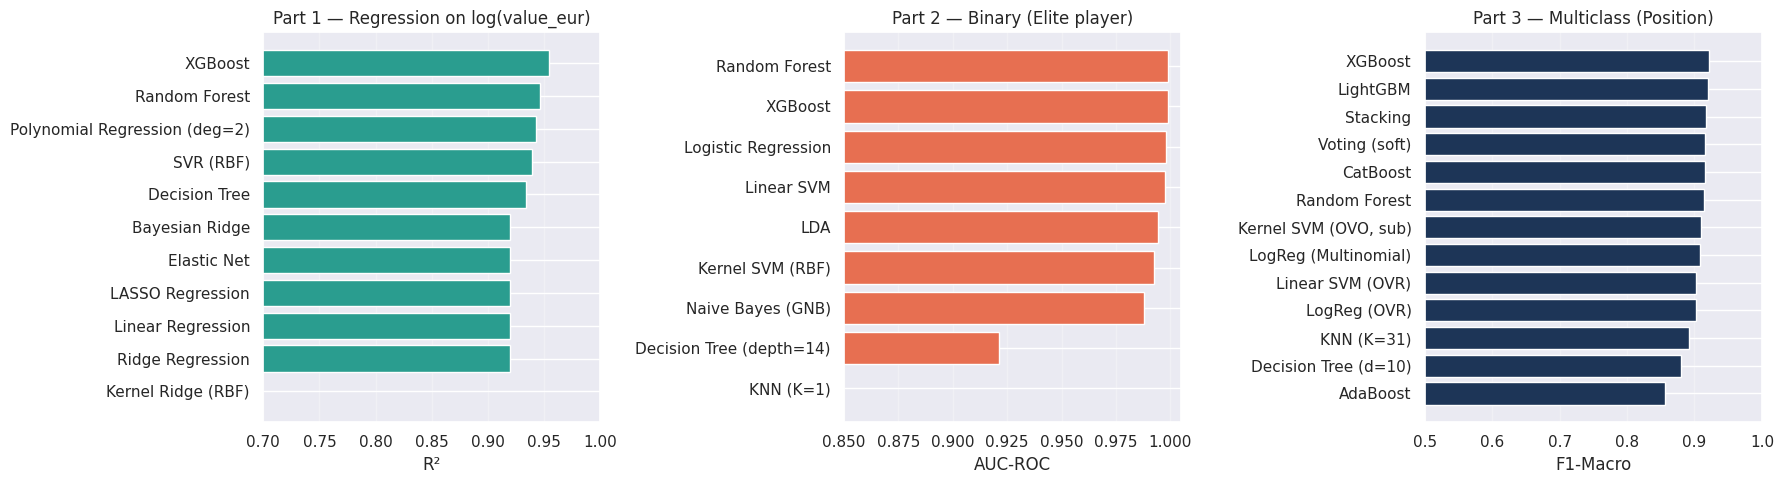

In [83]:
# Three-panel comparison: regression R² | binary AUC | multiclass F1-Macro
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Part 1 — Regression
reg_top = results_df.sort_values('R²', ascending=True)
axes[0].barh(reg_top.index, reg_top['R²'], color='#2a9d8f', edgecolor='white')
axes[0].set_xlabel('R²'); axes[0].set_title('Part 1 — Regression on log(value_eur)')
axes[0].set_xlim(0.7, 1.0); axes[0].grid(axis='x', alpha=.3)

# Part 2 — Binary
bin_top = clf_results_df.sort_values('AUC-ROC', ascending=True)
axes[1].barh(bin_top.index, bin_top['AUC-ROC'], color='#e76f51', edgecolor='white')
axes[1].set_xlabel('AUC-ROC'); axes[1].set_title('Part 2 — Binary (Elite player)')
axes[1].set_xlim(0.85, 1.005); axes[1].grid(axis='x', alpha=.3)

# Part 3 — Multiclass
mc_top = mc_results_df.sort_values('F1-Macro', ascending=True)
axes[2].barh(mc_top.index, mc_top['F1-Macro'], color='#1d3557', edgecolor='white')
axes[2].set_xlabel('F1-Macro'); axes[2].set_title('Part 3 — Multiclass (Position)')
axes[2].set_xlim(0.5, 1.0); axes[2].grid(axis='x', alpha=.3)

plt.tight_layout(); plt.show()


---
#  Section 4 — Challenging Questions (Bonus)

### 1. Bias–Variance trade-off in regression
* **Bias** = error from a model too simple to capture the truth (e.g. linear
  on a curved target).  High-bias models *underfit*.
* **Variance** = error from a model that follows training noise.  High-variance
  models *overfit* and change a lot if you re-sample the data.
* **Total expected error = Bias² + Variance + Irreducible noise.**
* Increasing model capacity (deeper trees, polynomial degree, smaller KNN K)
  lowers bias but raises variance. Regularisation, more data, and ensembling
  shift the curve down.

### 2. When does **Kernel Regression** beat Linear Regression?
When the true function is **non-linear in the original feature space** — e.g.
S-shaped, multi-modal, or contains interactions linear models cannot encode.
The kernel trick implicitly maps the input to an infinite-dimensional space
where the relationship becomes (approximately) linear, allowing it to fit
curves and bumps that ordinary least squares cannot. It loses to linear
regression when the truth really is linear (kernel adds variance for no bias
gain) and on very large datasets (O(n²–n³) compute).

### 3. L1 vs L2 — when LASSO vs Ridge; why LASSO is sparse
| | LASSO (L1) | Ridge (L2) |
|---|---|---|
| Penalty | Σ\|βᵢ\| | Σβᵢ² |
| Coefficients | **Exactly zero** for irrelevant features | Shrunk toward zero but rarely zero |
| Best when | Many features, only a few really matter | All features contribute a little; correlated features |
| Solution path | Piecewise linear, hits axes (sparsity) | Smooth shrinkage |

**Why LASSO is sparse:**
The L1 ball has corners on the axes. The squared-error contours grow as
ellipses; the first place they touch the constraint set is **usually at a
corner**, which means some coefficients are *exactly* zero. The L2 ball is a
smooth sphere with no corners, so the touch point is generically interior →
no exact zeros.

### 4. Why is **MAPE** unreliable on some datasets?
* It **explodes when actuals are near zero** (divides by tiny numbers).
* It is **asymmetric** — penalises over-prediction less than under-prediction
  for positive targets (capped at 100 % for under-prediction, unbounded above).
* Meaningless for targets that can be **negative or zero**.
* On our FIFA `value_eur`, many young players have value near €100 k while
  stars are at €100 M; MAPE on the low-value tail dominates the score.
  That is exactly why we log-transformed the target and reported MAPE only
  alongside RMSLE.

### 5. Effect of outliers on regression
Squared-error losses give outliers quadratically large gradients, so OLS,
Ridge, and Linear Regression can be **pulled heavily** by a few extreme points.
Solutions:
* **Robust losses** — Huber, quantile regression.
* **Tree models** — splits care only about ordering, not magnitudes.
* **Target transformations** — log, Yeo-Johnson, etc.
* **Detection / winsorising** before training.

### 6. Class imbalance and binary metrics — why **Accuracy misleads**
If 95 % of players are non-Elite, predicting "non-Elite" for every sample
gives **95 % accuracy with 0 % recall** on the Elite class. The model is
useless but the metric looks great.  Better metrics for imbalanced data:
**Precision / Recall**, **F1**, **PR-AUC**, **Balanced Accuracy**, **MCC**,
**Cohen's κ**. ROC-AUC is OK but can also be over-optimistic when the
negative class dominates.

### 7. Decision boundaries — how the models differ fundamentally
* **Logistic / Linear SVM** — boundary is a **hyperplane** in feature space.
* **Kernel SVM (RBF)** — boundary can be any smooth curve; controlled by γ.
* **KNN** — boundary is a **Voronoi-like piecewise constant** surface around
  training points; very wiggly for small K, smoother for large K.
* **Decision Tree** — **axis-aligned rectangular** regions; staircase boundary.
* **Random Forest / Boosting** — many staircase boundaries averaged → smooth-ish
  but still axis-aligned; cope with interactions and non-linearities natively.
* **Naive Bayes / LDA** — quadratic / linear surfaces from Gaussian densities.

### 8. Effect of K in KNN
* **K = 1** — fits training data exactly (variance maximal, bias minimal,
  prone to overfit & noise).
* **K → N** — predicts the global majority class everywhere (bias maximal,
  variance minimal).
* In between, K trades bias for variance. We pick K on validation data
  (we used CV on F1-Macro). Odd K is preferred for binary to avoid ties.

### 9. Decision tree overfitting
* **Why they overfit:** With enough depth, a tree can carve out one leaf per
  training sample → 100 % training accuracy on noise.
* **Why max-depth alone is not enough:** A shallow tree can still overfit if
  splits are made on features that appear discriminative by chance, or if a
  single leaf with very few samples is allowed. You also need
  `min_samples_leaf`, `min_samples_split`, `min_impurity_decrease`,
  `max_leaf_nodes`, etc.
* **Pruning:** Two flavours —
  *Pre-pruning* stops the tree growing once a quality criterion (min-impurity-
  decrease, min-samples) is no longer met.
  *Post-pruning* (cost-complexity, α) grows a full tree, then prunes back the
  weakest sub-trees, choosing α via cross-validation.

### 10. Why **tree-based models are good feature selectors**
At every split they pick the single feature that most reduces impurity (Gini,
entropy, MSE). Aggregating these reductions across all splits / trees yields
a natural ranking. Features that never get used contribute zero importance
and can be dropped — effectively **embedded feature selection** without an
extra step.

### 11. Micro vs Macro vs Weighted F1
* **Macro** = unweighted mean of per-class F1. **Best when every class
  matters equally** (rare-disease detection, minority groups).
* **Weighted** = mean of per-class F1 weighted by support. **Misleading when
  the rare class is the interesting one**, because the big classes drown its
  score.
* **Micro** = global F1 over the pooled confusion matrix.  In multiclass it
  is identical to plain accuracy, so it **favours large classes**.

### 12. Why **Multi-label ≠ Multiclass**
| Aspect | Multiclass | Multi-label |
|---|---|---|
| Output | One class per sample | Subset of classes per sample |
| Output space | {1..K} | {0,1}ᴷ (2ᴷ possibilities) |
| Loss | Cross-entropy / softmax | Binary cross-entropy per label, Hamming loss, exact-match |
| Thresholding | argmax | Per-label threshold (typically 0.5) |
| Metric | Accuracy, F1-Macro | Hamming, Jaccard, per-label F1, Subset accuracy |

**KNN / DT extend easily** because counting labels among the neighbours
(KNN) or in a leaf (tree) already supports multiple labels per training
example — just predict label-by-label.

### 13. Precision–Recall trade-off
For probability-based classifiers, lowering the decision threshold catches
more positives (↑ recall) but also flags more negatives (↓ precision). Raising
the threshold reverses the trade-off. The PR curve visualises every operating
point; you pick the threshold that matches the business cost ratio.

### 14. ROC vs PR curve
* **ROC** — TPR vs FPR. Insensitive to class prior; can look great on heavily
  imbalanced data even when the model is mediocre on the minority class.
* **PR** — Precision vs Recall. **Much more informative on imbalanced data**,
  because Precision drops fast when negatives flood the predictions.

### 15. Unlimited time / resources — how to improve our FIFA models
* **Preprocessing:** properly encode `nationality_name`, `league_name`,
  `club_name` (target encoding); engineer per-season age trajectories.
* **Features:** add interaction terms (`age × overall`, `pace × dribbling`),
  derive new ones from `player_positions` granularity (e.g. CB vs FB),
  compute "similar player" embeddings.
* **Models:** stack a calibrated deep-tabular model (TabNet / FT-Transformer)
  on top of the boosters, use Bayesian hyper-parameter search (Optuna), train
  per-position regressors and combine.
* **Metrics:** for the value-prediction task, evaluate by tier (top-1 %
  vs median), and use a **monotonic-in-money** loss (MAPE on log) rather than
  symmetric MSE.
* **Data:** combine multiple FIFA editions to capture **player trajectories
  over time**, opening the door to time-series forecasting (ARIMA / Prophet
  per player) and improving age-related extrapolation.
